# 07 — Echo Tops, VIL, VILD และตัวชี้วัดแกนพายุรุนแรง
## Echo Tops, Vertically Integrated Liquid, VIL Density and Severe-Storm Core Metrics

**กรณีศึกษา**

- Radar site: **Omkoi**
- Agency: **Department of Royal Rainmaking and Agricultural Aviation (DRRAA)**
- Radar band: **S-band**
- Event: **observed hail event**
- Date: **18 March 2023**
- Native radar volumes: **10 scans**
- Peak representative volume: อ่านจาก Notebook 03/06
- 3-D storm-focused grid: อ่านจาก Notebook 03
- Vertical-structure diagnostics: อ่านจาก Notebook 06
- Figure text: **English only**
- Teaching explanation: **ภาษาไทย**

---

## แนวคิดหลักของบท

Notebook 06 สอนให้เข้าใจโครงสร้างพายุในแนวดิ่งก่อน

Notebook 07 จะเปลี่ยน vertical structure ให้เป็น **automated severe-storm metrics**

```text
3-D corrected reflectivity
        ↓
Composite reflectivity
        ↓
Height of maximum reflectivity
        ↓
ET20 / ET30 / ET40 / ET50
        ↓
VIL
        ↓
VIL density
        ↓
40 / 50-dBZ footprint and echo volume
        ↓
Largest severe-convective core
        ↓
10-volume storm lifecycle
```

> **หลักสำคัญ**
>
> `Echo top is threshold dependent`
>
> `VIL is a reflectivity-derived proxy, not measured liquid water`
>
> `VIL density is not a universal hail threshold`
>
> `High VIL / VILD does not by itself prove hail`
>
> `Thresholds developed in the United States must not be transferred directly to tropical Thailand without validation`

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 07 ผู้เรียนควรสามารถ:

1. อธิบาย composite reflectivity จาก 3-D volume
2. คำนวณ height of maximum reflectivity
3. คำนวณ ET20, ET30, ET40 และ ET50
4. ใช้ linear interpolation ระหว่าง vertical levels เพื่อประมาณ threshold crossing
5. ตรวจ top censoring ที่ grid ceiling
6. อธิบายความแตกต่างระหว่าง ET20 และ ET50
7. อธิบายหลักการของ Vertically Integrated Liquid (VIL)
8. แปลง dBZ เป็น linear reflectivity factor
9. ใช้ reflectivity cap ที่ 56 dBZ สำหรับ VIL sensitivity
10. อธิบายเหตุผลของ 18–18.5 dBZ lower threshold ใน VIL/VILD literature
11. คำนวณ VIL หน่วย kg m⁻²
12. เปรียบเทียบ capped และ uncapped VIL
13. คำนวณ VIL density
14. แยก VILD ที่ normalized ด้วย echo-top height ออกจาก VILD ที่ normalized ด้วย echo depth
15. อธิบายเหตุผลที่ published VILD thresholds ไม่ควรใช้ตรง ๆ กับประเทศไทย
16. คำนวณ 40-dBZ และ 50-dBZ footprint area
17. คำนวณ 40-dBZ และ 50-dBZ echo volume
18. ระบุ largest 40-dBZ severe-convective core
19. คำนวณ severe-core centroid และ area
20. สร้าง professional maps ของ ET, VIL และ VILD
21. export severe-storm products เป็น GeoTIFF
22. ประมวลผล radar volumes ทั้ง 10 scans
23. ใช้ dynamic storm-centered 3-D grid
24. ตรวจว่า severe core แตะขอบ analysis grid หรือไม่
25. สร้าง time series ของ max ZH, ET40, ET50, VIL, VILD และ echo volume
26. อธิบาย storm growth, mature และ decay phases
27. export event-lifecycle CSV
28. เตรียมข้อมูลสำหรับ Notebook 08 — hail retrieval / MESH / pyhail

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**EXPERIMENT** — sensitivity test  
**RESEARCH NOTE** — ประเด็นสำหรับ manuscript / publication

# 1. Echo Top เป็น threshold-based quantity

Echo top ไม่ใช่ค่าหนึ่งเดียว

ตัวอย่าง:

$$
ET_{20}
=
\max
\left\{
z:
Z_H(z)\ge20\;dBZ
\right\}
$$

และ:

$$
ET_{50}
=
\max
\left\{
z:
Z_H(z)\ge50\;dBZ
\right\}
$$

ดังนั้น:

```text
ET20
= vertical extent ของ broader precipitation echo

ET40
= vertical extent ของ strong convective core

ET50
= vertical extent ของ very intense reflectivity core
```

โดยทั่วไป:

$$
ET_{20}
\ge
ET_{30}
\ge
ET_{40}
\ge
ET_{50}
$$

แต่ค่าเหล่านี้ขึ้นกับ:

- radar sampling
- attenuation / calibration
- interpolation
- vertical grid spacing
- threshold definition

# 2. Linear interpolation ของ echo top

ถ้า Cartesian grid มี vertical spacing 0.5 km และ threshold 40 dBZ อยู่ระหว่างสองระดับ:

```text
7.0 km → 44 dBZ
7.5 km → 35 dBZ
```

การใช้เพียง highest grid level จะให้:

```text
ET40 = 7.0 km
```

แต่สามารถประมาณ threshold crossing ด้วย linear interpolation:

$$
z_T
=
z_1
+
\frac{T-Z_1}{Z_2-Z_1}
\left(
z_2-z_1
\right)
$$

วิธีนี้ไม่สร้าง observational resolution ใหม่

แต่ลด quantization จาก vertical grid spacing

# 3. Vertically Integrated Liquid — VIL

แนวคิด VIL ใช้ radar reflectivity เพื่อสร้าง **equivalent liquid-water proxy**

ความสัมพันธ์ที่ใช้ทั่วไป:

$$
M
=
3.44\times10^{-6}
Z^{4/7}
$$

เมื่อ:

- $M$ = equivalent liquid water content, kg m⁻³
- $Z$ = linear radar reflectivity factor, mm⁶ m⁻³

จากนั้น:

$$
VIL
=
\int
M(z)\,dz
$$

หน่วย:

$$
kg\,m^{-2}
$$

หรือเขียนรวมเป็น:

$$
VIL
=
3.44\times10^{-6}
\int
Z^{4/7}
dz
$$

> **สำคัญ**
>
> VIL ไม่ใช่ปริมาณน้ำเหลวจริงในพายุ  
> แต่เป็น reflectivity-derived proxy

# 4. ทำไม VIL จึงใช้ reflectivity cap 56 dBZ

Reflectivity จาก hail หรือ large ice particles สามารถสูงมาก

ถ้านำค่าที่สูงมากเข้าสมการ VIL โดยตรง:

$$
Z_H
\rightarrow
Z
\rightarrow
Z^{4/7}
$$

VIL จะเพิ่มขึ้นมาก

Operational VIL implementations จึงมักจำกัด reflectivity สูงสุดที่ประมาณ:

```text
56 dBZ
```

เพื่อจำกัดผลกระทบจาก hail contamination

Notebook นี้จึงคำนวณสองแบบ:

```text
VIL56
= capped at 56 dBZ

VIL_uncapped
= no upper reflectivity cap
```

การเปรียบเทียบสองแบบคือ **sensitivity analysis**

# 5. VIL Density — VILD

Amburn and Wolf (1997) เสนอแนวคิด:

$$
VILD
=
\frac{VIL}{Echo\ Top}
$$

เมื่อแปลงหน่วยเป็น g m⁻³:

$$
VILD
=
1000
\frac{
VIL\;[kg\,m^{-2}]
}{
H\;[m]
}
$$

งาน operational หลายระบบใช้ 18–18.5 dBZ echo top เป็น denominator

Notebook นี้จะคำนวณสอง metric:

### 1. VILD18-ARL

$$
VILD_{18,ARL}
=
1000
\frac{
VIL
}{
ET_{18.5}-H_{radar}
}
$$

คือ normalize ด้วย 18.5-dBZ top height เหนือระดับ radar

### 2. VILD18-depth

$$
VILD_{18,depth}
=
1000
\frac{
VIL
}{
ET_{18.5}-EB_{18.5}
}
$$

คือ normalize ด้วย vertical echo depth

ตัวที่สองช่วยลดปัญหาบางส่วนเมื่อ lower-level radar coverage ไม่สมบูรณ์

> **RESEARCH NOTE**
>
> published severe-hail thresholds เช่น 3.5–4.0 g m⁻³ มาจากบริบท radar, climatology และ hail criteria อื่น  
> **ห้ามใช้เป็น deterministic threshold สำหรับประเทศไทยโดยไม่ validation**

# 6. Severe-core area และ echo volume

สำหรับ threshold $T$:

### Horizontal footprint

$$
A_T
=
N_{xy,T}
\Delta x
\Delta y
$$

หน่วย km²

### Three-dimensional echo volume

$$
V_T
=
N_{xyz,T}
\Delta x
\Delta y
\Delta z
$$

หน่วย km³

ตัวอย่าง:

```text
40-dBZ footprint area
50-dBZ footprint area

40-dBZ echo volume
50-dBZ echo volume
```

ค่าพวกนี้ช่วยอธิบายทั้ง:

```text
horizontal size
+
vertical depth
```

ของ intense convective core

# 7. ติดตั้งไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — Install Notebook 07 packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "numpy>=1.26",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "scipy>=1.12",
    "netCDF4>=1.6",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 07 ...")
subprocess.check_call(cmd)
print("พร้อมใช้งาน")

กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 07 ...
พร้อมใช้งาน


# 8. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "ไม่พบ google.colab — "
        "ใช้โฟลเดอร์ปัจจุบันแทน:"
    )

    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 9. นำเข้าไลบรารีและกำหนดมาตรฐานรูป

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import ast
import gc
import gzip
import json
import math
import shutil
import sys
import tempfile
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import pyart

from netCDF4 import num2date

from scipy import ndimage

from rasterio.transform import from_origin
import rasterio

from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,rasterio,1.5.1


In [4]:
# CELL 4 — Publication plotting standard

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )


def resolve_reflectivity_colormap():
    for candidate in [
        "NWSRef",
        "HomeyerRainbow",
        "Carbone11",
        "turbo",
    ]:
        if candidate in matplotlib.colormaps:
            return candidate

    return "viridis"


ZH_CMAP = resolve_reflectivity_colormap()

print(
    "Reflectivity colormap:",
    ZH_CMAP,
)

Reflectivity colormap: NWSRef


# 10. อ่าน configuration และ readiness จาก Notebook ก่อนหน้า

Notebook 07 ต้องใช้:

```text
Notebook 03
→ 3-D Cartesian grids

Notebook 06
→ vertical-structure validation
```

ดังนั้นจะตรวจ:

```text
03_readiness_check.csv
06_readiness_check.csv
03_grid_configuration.csv
06_vertical_structure_summary.csv
```

หาก Notebook 06 ยังไม่ผ่าน จะหยุดก่อนคำนวณ severe-storm metrics

In [5]:
# CELL 5 — Load course configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ course_config.json — ให้รัน Notebook 01 ก่อน"
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Active event ไม่ใช่ observed_hail"
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

Active event: 20230318_observed_hail_1106_1200


In [6]:
# CELL 6 — Paths and readiness

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_NETCDF_DIR = (
    EVENT_ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "07"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

READINESS_06_CSV = (
    OUTPUT_CSV_DIR
    / "06_readiness_check.csv"
)

GRID_CONFIG_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

VERTICAL_SUMMARY_06_CSV = (
    OUTPUT_CSV_DIR
    / "06_vertical_structure_summary.csv"
)

for required_file in [
    READINESS_03_CSV,
    READINESS_06_CSV,
    GRID_CONFIG_03_CSV,
    VERTICAL_SUMMARY_06_CSV,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"ไม่พบไฟล์ที่ต้องใช้: {required_file}"
        )


readiness_03 = pd.read_csv(
    READINESS_03_CSV
)

readiness_06 = pd.read_csv(
    READINESS_06_CSV
)

if not (
    readiness_03[
        "status"
    ]
    == "PASS"
).all():
    raise RuntimeError(
        "Notebook 03 readiness ยังไม่ผ่าน"
    )

if not (
    readiness_06[
        "status"
    ]
    == "PASS"
).all():
    display(
        readiness_06
    )

    raise RuntimeError(
        "Notebook 06 readiness ยังไม่ผ่าน"
    )


grid_config_03 = pd.read_csv(
    GRID_CONFIG_03_CSV
)

grid_config_lookup = dict(
    zip(
        grid_config_03[
            "parameter"
        ],
        grid_config_03[
            "value"
        ],
    )
)

vertical_summary_06 = pd.read_csv(
    VERTICAL_SUMMARY_06_CSV
)

print(
    "Notebook 03 readiness: PASS"
)

print(
    "Notebook 06 readiness: PASS"
)

Notebook 03 readiness: PASS
Notebook 06 readiness: PASS


# 11. Parameter block

ค่าหลักของ Notebook 07:

```text
ET maps             = 20 / 30 / 40 / 50 dBZ
VIL lower threshold = 18.5 dBZ
VIL upper cap       = 56 dBZ
Core footprint      = 40 dBZ
Intense core        = 50 dBZ
```

สำหรับ lifecycle ทั้ง 10 scans จะใช้ dynamic storm-centered grid:

```text
horizontal spacing = 1 km
vertical levels    = ใช้ช่วงเดียวกับ storm grid จาก Notebook 03
half-width         = 90 km
```

เหตุผล:

- ลด computation
- ตาม storm complex ได้
- ไม่จำเป็นต้องให้ทุก scan อยู่บน x/y grid เดียวกัน เพราะ lifecycle ใช้ scalar storm metrics

In [7]:
# CELL 7 — Scientific parameters

FIELD_Z = str(
    grid_config_lookup[
        "field"
    ]
)

SELECTED_FILENAME = str(
    grid_config_lookup[
        "source_file"
    ]
)

TARGET_AZIMUTH_DEG = float(
    grid_config_lookup[
        "strong_echo_reference_azimuth_deg"
    ]
)

CORE_REFERENCE_RANGE_KM = float(
    grid_config_lookup[
        "strong_echo_reference_range_km"
    ]
)

RADAR_ALTITUDE_M_MSL = float(
    grid_config_lookup[
        "radar_altitude_m_MSL"
    ]
)

RADAR_LAT = float(
    grid_config_lookup[
        "radar_latitude_deg"
    ]
)

RADAR_LON = float(
    grid_config_lookup[
        "radar_longitude_deg"
    ]
)

ET_THRESHOLDS_DBZ = [
    20.0,
    30.0,
    40.0,
    50.0,
]

VIL_ECHO_THRESHOLD_DBZ = 18.5

VIL_CAP_DBZ = 56.0

CORE_FOOTPRINT_THRESHOLD_DBZ = 40.0

INTENSE_CORE_THRESHOLD_DBZ = 50.0

LIFECYCLE_GRID_DX_KM = 1.0

LIFECYCLE_HALF_WIDTH_KM = 90.0

CORE_SEARCH_HALF_ANGLE_DEG = 45.0

CORE_SEARCH_MIN_RANGE_KM = max(
    25.0,
    CORE_REFERENCE_RANGE_KM
    * 0.35,
)

CORE_SEARCH_MAX_RANGE_KM = min(
    220.0,
    CORE_REFERENCE_RANGE_KM
    * 1.90,
)

CORE_SEARCH_THRESHOLDS_DBZ = [
    40.0,
    35.0,
    30.0,
]

GEOTIFF_NODATA = -9999.0

print(
    "ET thresholds:",
    ET_THRESHOLDS_DBZ,
)

print(
    "VIL threshold:",
    VIL_ECHO_THRESHOLD_DBZ,
    "dBZ",
)

print(
    "VIL cap:",
    VIL_CAP_DBZ,
    "dBZ",
)

print(
    "Lifecycle storm-following grid half-width:",
    LIFECYCLE_HALF_WIDTH_KM,
    "km",
)

ET thresholds: [20.0, 30.0, 40.0, 50.0]
VIL threshold: 18.5 dBZ
VIL cap: 56.0 dBZ
Lifecycle storm-following grid half-width: 90.0 km


# 12. อ่าน peak storm-focused 3-D grid

Peak-volume maps จะใช้ storm-focused 0.5-km grid จาก Notebook 03

นี่ทำให้ Notebook 06 และ 07 วิเคราะห์ **storm representation เดียวกัน**

In [8]:
# CELL 8 — Read peak storm-focused 3-D grid

configured_storm_grid = Path(
    str(
        grid_config_lookup[
            "storm_grid_NetCDF"
        ]
    )
)

if configured_storm_grid.exists():
    STORM_GRID_NETCDF = (
        configured_storm_grid
    )

else:
    candidates = sorted(
        OUTPUT_NETCDF_DIR.glob(
            "03_peak_storm_focus_3D_ZH_*UTC.nc"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "ไม่พบ storm-focused 3-D Grid NetCDF"
        )

    STORM_GRID_NETCDF = (
        candidates[
            -1
        ]
    )


storm_grid = pyart.io.read_grid(
    str(
        STORM_GRID_NETCDF
    )
)

if FIELD_Z not in storm_grid.fields:
    raise KeyError(
        f"ไม่พบ field {FIELD_Z} ใน storm grid"
    )

STORM_ZH = np.ma.asarray(
    storm_grid.fields[
        FIELD_Z
    ][
        "data"
    ]
)

STORM_X_KM = (
    np.asarray(
        storm_grid.x[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

STORM_Y_KM = (
    np.asarray(
        storm_grid.y[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

STORM_Z_KM_MSL = (
    np.asarray(
        storm_grid.z[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

STORM_DX_KM = float(
    np.nanmedian(
        np.diff(
            STORM_X_KM
        )
    )
)

STORM_DY_KM = float(
    np.nanmedian(
        np.diff(
            STORM_Y_KM
        )
    )
)

STORM_DZ_KM = float(
    np.nanmedian(
        np.diff(
            STORM_Z_KM_MSL
        )
    )
)

print(
    "Storm-grid shape:",
    STORM_ZH.shape,
)

print(
    "Spacing:",
    f"{STORM_DX_KM:.2f} × {STORM_DY_KM:.2f} × {STORM_DZ_KM:.2f} km",
)

print(
    "Vertical range:",
    f"{STORM_Z_KM_MSL.min():.2f}–"
    f"{STORM_Z_KM_MSL.max():.2f} km MSL",
)

Storm-grid shape: (38, 329, 422)
Spacing: 0.50 × 0.50 × 0.50 km
Vertical range: 1.50–20.00 km MSL


# 13. ตรวจ vertical coordinate

VIL integration ใช้ layer depth เป็นเมตร

ดังนั้นต้องตรวจว่า:

```text
z levels increasing upward
vertical spacing positive
```

และสำหรับ VILD18-ARL:

```text
ET18.5_ARL
=
ET18.5_MSL
− radar altitude MSL
```

In [9]:
# CELL 9 — Vertical-coordinate QC

if not np.all(
    np.diff(
        STORM_Z_KM_MSL
    )
    > 0.0
):
    raise RuntimeError(
        "Vertical grid levels ไม่ได้เรียงเพิ่มขึ้น"
    )

if STORM_DZ_KM <= 0.0:
    raise RuntimeError(
        "Vertical grid spacing ไม่ถูกต้อง"
    )

RADAR_ALTITUDE_KM_MSL = (
    RADAR_ALTITUDE_M_MSL
    / 1000.0
)

print(
    "Radar altitude:",
    f"{RADAR_ALTITUDE_KM_MSL:.3f} km MSL",
)

Radar altitude: 1.173 km MSL


# 14. ฟังก์ชันคำนวณ threshold-top แบบ interpolated

สำหรับแต่ละ column จะหา highest level ที่:

```text
ZH ≥ threshold
```

ถ้าระดับถัดขึ้นไปมีค่าต่ำกว่า threshold จะ interpolate ระหว่างสองระดับ

หาก threshold ยังมีอยู่ที่ grid level บนสุด จะ flag:

```text
top_censored = True
```

เพราะเราไม่ทราบว่า echo สูงเกิน grid ceiling อีกเท่าใด

In [10]:
# CELL 10 — Interpolated threshold-top and base

def threshold_top_base_3d(
    field_3d,
    z_km,
    threshold_dbz,
):
    field = np.ma.asarray(
        field_3d
    ).filled(
        np.nan
    )

    nz, ny, nx = (
        field.shape
    )

    top = np.full(
        (
            ny,
            nx,
        ),
        np.nan,
        dtype=float,
    )

    base = np.full(
        (
            ny,
            nx,
        ),
        np.nan,
        dtype=float,
    )

    top_censored = np.zeros(
        (
            ny,
            nx,
        ),
        dtype=bool,
    )

    base_censored = np.zeros(
        (
            ny,
            nx,
        ),
        dtype=bool,
    )

    for iy in range(
        ny
    ):
        for ix in range(
            nx
        ):
            column = (
                field[
                    :,
                    iy,
                    ix
                ]
            )

            hits = np.where(
                np.isfinite(
                    column
                )
                & (
                    column
                    >= threshold_dbz
                )
            )[0]

            if hits.size == 0:
                continue

            bottom_index = int(
                hits[
                    0
                ]
            )

            top_index = int(
                hits[
                    -1
                ]
            )

            # Base
            if bottom_index == 0:
                base[
                    iy,
                    ix
                ] = z_km[
                    bottom_index
                ]

                base_censored[
                    iy,
                    ix
                ] = True

            else:
                z0 = float(
                    z_km[
                        bottom_index
                        - 1
                    ]
                )

                z1 = float(
                    z_km[
                        bottom_index
                    ]
                )

                v0 = column[
                    bottom_index
                    - 1
                ]

                v1 = column[
                    bottom_index
                ]

                if (
                    np.isfinite(
                        v0
                    )
                    and np.isfinite(
                        v1
                    )
                    and v1 != v0
                ):
                    fraction = (
                        threshold_dbz
                        - v0
                    ) / (
                        v1
                        - v0
                    )

                    base[
                        iy,
                        ix
                    ] = (
                        z0
                        + fraction
                        * (
                            z1
                            - z0
                        )
                    )

                else:
                    base[
                        iy,
                        ix
                    ] = z1

            # Top
            if top_index == (
                nz
                - 1
            ):
                top[
                    iy,
                    ix
                ] = z_km[
                    top_index
                ]

                top_censored[
                    iy,
                    ix
                ] = True

            else:
                z1 = float(
                    z_km[
                        top_index
                    ]
                )

                z2 = float(
                    z_km[
                        top_index
                        + 1
                    ]
                )

                v1 = column[
                    top_index
                ]

                v2 = column[
                    top_index
                    + 1
                ]

                if (
                    np.isfinite(
                        v1
                    )
                    and np.isfinite(
                        v2
                    )
                    and v2 != v1
                ):
                    fraction = (
                        threshold_dbz
                        - v1
                    ) / (
                        v2
                        - v1
                    )

                    top[
                        iy,
                        ix
                    ] = (
                        z1
                        + fraction
                        * (
                            z2
                            - z1
                        )
                    )

                else:
                    top[
                        iy,
                        ix
                    ] = z1

    return {
        "top_km_MSL": (
            top
        ),
        "base_km_MSL": (
            base
        ),
        "top_censored": (
            top_censored
        ),
        "base_censored": (
            base_censored
        ),
    }

# 15. Composite reflectivity และ height of maximum ZH

Composite reflectivity:

$$
Z_{comp}(x,y)
=
\max_z
Z_H(x,y,z)
$$

Height of maximum reflectivity:

$$
H_{maxZ}(x,y)
=
z
\left[
\arg\max_z
Z_H(x,y,z)
\right]
$$

In [11]:
# CELL 11 — Column maximum diagnostics

def column_maximum_metrics(
    field_3d,
    z_km,
):
    field = np.ma.asarray(
        field_3d
    ).filled(
        np.nan
    )

    valid_column = np.any(
        np.isfinite(
            field
        ),
        axis=0,
    )

    filled_for_argmax = np.where(
        np.isfinite(
            field
        ),
        field,
        -np.inf,
    )

    max_index = np.argmax(
        filled_for_argmax,
        axis=0,
    )

    composite = np.max(
        filled_for_argmax,
        axis=0,
    )

    composite[
        ~valid_column
    ] = np.nan

    height = z_km[
        max_index
    ].astype(
        float
    )

    height[
        ~valid_column
    ] = np.nan

    return {
        "composite_ZH_dBZ": (
            composite
        ),
        "height_of_max_ZH_km_MSL": (
            height
        ),
    }

# 16. ฟังก์ชัน VIL

ขั้นตอน:

```text
dBZ
↓
cap at 56 dBZ (standard-like VIL56)
↓
linear Z
↓
equivalent liquid-water proxy
↓
vertical trapezoidal integration
```

สำหรับ valid reflectivity ต่ำกว่า 18.5 dBZ จะให้ contribution = 0

masked / unsupported grid cells จะไม่มี contribution ใน teaching implementation นี้

จึงต้องตีความ VIL ร่วมกับ radar sampling และ echo-top diagnostics

In [12]:
# CELL 12 — VIL calculator

def calculate_vil(
    field_3d,
    z_km,
    *,
    lower_threshold_dbz=18.5,
    upper_cap_dbz=56.0,
):
    field = np.ma.asarray(
        field_3d
    ).filled(
        np.nan
    )

    if upper_cap_dbz is None:
        processed_dbz = field.copy()

    else:
        processed_dbz = np.minimum(
            field,
            float(
                upper_cap_dbz
            ),
        )

    qualifying = (
        np.isfinite(
            processed_dbz
        )
        & (
            processed_dbz
            >= lower_threshold_dbz
        )
    )

    linear_z = np.zeros_like(
        processed_dbz,
        dtype=float,
    )

    linear_z[
        qualifying
    ] = np.power(
        10.0,
        processed_dbz[
            qualifying
        ]
        / 10.0,
    )

    equivalent_lwc_kg_m3 = np.zeros_like(
        processed_dbz,
        dtype=float,
    )

    equivalent_lwc_kg_m3[
        qualifying
    ] = (
        3.44e-6
        * np.power(
            linear_z[
                qualifying
            ],
            4.0
            / 7.0,
        )
    )

    z_m = (
        np.asarray(
            z_km,
            dtype=float,
        )
        * 1000.0
    )

    dz_m = np.diff(
        z_m
    )

    layer_mean_lwc = (
        0.5
        * (
            equivalent_lwc_kg_m3[
                :-1
            ]
            + equivalent_lwc_kg_m3[
                1:
            ]
        )
    )

    layer_vil = (
        layer_mean_lwc
        * dz_m[
            :,
            None,
            None
        ]
    )

    vil_kg_m2 = np.sum(
        layer_vil,
        axis=0,
    )

    any_echo = np.any(
        qualifying,
        axis=0,
    )

    vil_kg_m2[
        ~any_echo
    ] = np.nan

    return {
        "VIL_kg_m2": (
            vil_kg_m2
        ),
        "equivalent_LWC_kg_m3": (
            equivalent_lwc_kg_m3
        ),
        "qualifying_echo": (
            qualifying
        ),
    }

# 17. ฟังก์ชัน VIL density

Notebook จะไม่ใช้ VILD เป็นตัวตัดสิน hail แบบ binary

คำนวณสอง denominator:

```text
VILD18_ARL
= VIL / 18.5-dBZ top height above radar

VILD18_depth
= VIL / 18.5-dBZ echo depth
```

หน่วยสุดท้าย:

```text
g m⁻³
```

In [13]:
# CELL 13 — VILD calculator

def calculate_vild(
    vil_kg_m2,
    *,
    et18_km_MSL,
    eb18_km_MSL,
    radar_altitude_km_MSL,
):
    vil = np.asarray(
        vil_kg_m2,
        dtype=float,
    )

    et18 = np.asarray(
        et18_km_MSL,
        dtype=float,
    )

    eb18 = np.asarray(
        eb18_km_MSL,
        dtype=float,
    )

    top_height_ARL_m = (
        (
            et18
            - radar_altitude_km_MSL
        )
        * 1000.0
    )

    echo_depth_m = (
        (
            et18
            - eb18
        )
        * 1000.0
    )

    vild_arl = np.full_like(
        vil,
        np.nan,
        dtype=float,
    )

    vild_depth = np.full_like(
        vil,
        np.nan,
        dtype=float,
    )

    valid_arl = (
        np.isfinite(
            vil
        )
        & np.isfinite(
            top_height_ARL_m
        )
        & (
            top_height_ARL_m
            > 0.0
        )
    )

    valid_depth = (
        np.isfinite(
            vil
        )
        & np.isfinite(
            echo_depth_m
        )
        & (
            echo_depth_m
            > 0.0
        )
    )

    vild_arl[
        valid_arl
    ] = (
        1000.0
        * vil[
            valid_arl
        ]
        / top_height_ARL_m[
            valid_arl
        ]
    )

    vild_depth[
        valid_depth
    ] = (
        1000.0
        * vil[
            valid_depth
        ]
        / echo_depth_m[
            valid_depth
        ]
    )

    return {
        "VILD18_ARL_g_m3": (
            vild_arl
        ),
        "VILD18_depth_g_m3": (
            vild_depth
        ),
        "ET18_height_ARL_m": (
            top_height_ARL_m
        ),
        "echo_depth18_m": (
            echo_depth_m
        ),
    }

# 18. Largest severe-core footprint

Composite reflectivity ≥40 dBZ อาจมีหลาย objects

Notebook จะใช้ connected-component labeling แบบ 8-neighbor แล้วเลือก object ที่มีพื้นที่มากที่สุด

นี่เป็น **severe-convective core footprint**

ยังไม่ใช่ full storm-cell tracking algorithm

Notebook 07 ใช้เพียงเพื่อ:

- แยก main severe core
- ลดการปนกับ isolated intense echoes
- สร้าง scalar lifecycle metrics ที่สอดคล้องกัน

In [14]:
# CELL 14 — Largest connected severe-core footprint

def largest_connected_core(
    composite_dbz,
    threshold_dbz=40.0,
):
    composite = np.asarray(
        composite_dbz,
        dtype=float,
    )

    binary = (
        np.isfinite(
            composite
        )
        & (
            composite
            >= threshold_dbz
        )
    )

    structure = np.ones(
        (
            3,
            3,
        ),
        dtype=int,
    )

    labels, n_labels = ndimage.label(
        binary,
        structure=structure,
    )

    if n_labels == 0:
        return {
            "mask": np.zeros_like(
                binary,
                dtype=bool,
            ),
            "label": 0,
            "pixel_count": 0,
            "n_objects": 0,
        }

    label_ids = np.arange(
        1,
        n_labels
        + 1,
    )

    sizes = ndimage.sum(
        binary,
        labels=labels,
        index=label_ids,
    )

    largest_index = int(
        np.argmax(
            sizes
        )
    )

    largest_label = int(
        label_ids[
            largest_index
        ]
    )

    largest_mask = (
        labels
        == largest_label
    )

    return {
        "mask": (
            largest_mask
        ),
        "label": (
            largest_label
        ),
        "pixel_count": int(
            largest_mask.sum()
        ),
        "n_objects": int(
            n_labels
        ),
    }

In [15]:
# CELL 15 — General severe-metric calculator

def severe_metrics_from_grid(
    field_3d,
    x_km,
    y_km,
    z_km_MSL,
    *,
    radar_altitude_km_MSL,
    core_threshold_dbz=40.0,
):
    field = np.ma.asarray(
        field_3d
    )

    dx_km = float(
        np.nanmedian(
            np.diff(
                x_km
            )
        )
    )

    dy_km = float(
        np.nanmedian(
            np.diff(
                y_km
            )
        )
    )

    dz_km = float(
        np.nanmedian(
            np.diff(
                z_km_MSL
            )
        )
    )

    column_metrics = (
        column_maximum_metrics(
            field,
            z_km_MSL,
        )
    )

    composite = (
        column_metrics[
            "composite_ZH_dBZ"
        ]
    )

    height_max = (
        column_metrics[
            "height_of_max_ZH_km_MSL"
        ]
    )

    threshold_products = {}

    for threshold in (
        ET_THRESHOLDS_DBZ
        + [
            VIL_ECHO_THRESHOLD_DBZ
        ]
    ):
        threshold_products[
            threshold
        ] = (
            threshold_top_base_3d(
                field,
                z_km_MSL,
                threshold,
            )
        )

    vil56 = calculate_vil(
        field,
        z_km_MSL,
        lower_threshold_dbz=(
            VIL_ECHO_THRESHOLD_DBZ
        ),
        upper_cap_dbz=(
            VIL_CAP_DBZ
        ),
    )

    vil_uncapped = calculate_vil(
        field,
        z_km_MSL,
        lower_threshold_dbz=(
            VIL_ECHO_THRESHOLD_DBZ
        ),
        upper_cap_dbz=None,
    )

    et18 = (
        threshold_products[
            VIL_ECHO_THRESHOLD_DBZ
        ][
            "top_km_MSL"
        ]
    )

    eb18 = (
        threshold_products[
            VIL_ECHO_THRESHOLD_DBZ
        ][
            "base_km_MSL"
        ]
    )

    vild = calculate_vild(
        vil56[
            "VIL_kg_m2"
        ],
        et18_km_MSL=(
            et18
        ),
        eb18_km_MSL=(
            eb18
        ),
        radar_altitude_km_MSL=(
            radar_altitude_km_MSL
        ),
    )

    core_object = largest_connected_core(
        composite,
        threshold_dbz=(
            core_threshold_dbz
        ),
    )

    core_mask = (
        core_object[
            "mask"
        ]
    )

    X2D, Y2D = np.meshgrid(
        x_km,
        y_km,
    )

    if core_mask.any():
        core_centroid_x_km = float(
            np.nanmean(
                X2D[
                    core_mask
                ]
            )
        )

        core_centroid_y_km = float(
            np.nanmean(
                Y2D[
                    core_mask
                ]
            )
        )

    else:
        core_centroid_x_km = np.nan
        core_centroid_y_km = np.nan

    core_3d_mask = (
        core_mask[
            None,
            :,
            :
        ]
    )

    field_values = np.ma.asarray(
        field
    ).filled(
        np.nan
    )

    core_area_km2 = (
        core_mask.sum()
        * dx_km
        * dy_km
    )

    footprint50 = (
        np.isfinite(
            composite
        )
        & (
            composite
            >= INTENSE_CORE_THRESHOLD_DBZ
        )
        & core_mask
    )

    footprint50_area_km2 = (
        footprint50.sum()
        * dx_km
        * dy_km
    )

    volume40_mask = (
        np.isfinite(
            field_values
        )
        & (
            field_values
            >= 40.0
        )
        & core_3d_mask
    )

    volume50_mask = (
        np.isfinite(
            field_values
        )
        & (
            field_values
            >= 50.0
        )
        & core_3d_mask
    )

    cell_volume_km3 = (
        dx_km
        * dy_km
        * dz_km
    )

    echo_volume40_km3 = (
        volume40_mask.sum()
        * cell_volume_km3
    )

    echo_volume50_km3 = (
        volume50_mask.sum()
        * cell_volume_km3
    )

    def masked_max(
        array_2d,
        mask_2d,
    ):
        array = np.asarray(
            array_2d,
            dtype=float,
        )

        valid = (
            mask_2d
            & np.isfinite(
                array
            )
        )

        if not valid.any():
            return np.nan

        return float(
            np.nanmax(
                array[
                    valid
                ]
            )
        )

    core_max_zh = masked_max(
        composite,
        core_mask,
    )

    core_field = np.where(
        core_3d_mask
        & np.isfinite(
            field_values
        ),
        field_values,
        np.nan,
    )

    if np.isfinite(
        core_field
    ).any():
        core_flat_max = int(
            np.nanargmax(
                core_field
            )
        )

        core_z_index, core_y_index, core_x_index = (
            np.unravel_index(
                core_flat_max,
                core_field.shape,
            )
        )

        height_of_core_maximum_ZH_km_MSL = float(
            z_km_MSL[
                core_z_index
            ]
        )

        x_of_core_maximum_ZH_km = float(
            x_km[
                core_x_index
            ]
        )

        y_of_core_maximum_ZH_km = float(
            y_km[
                core_y_index
            ]
        )

    else:
        height_of_core_maximum_ZH_km_MSL = np.nan
        x_of_core_maximum_ZH_km = np.nan
        y_of_core_maximum_ZH_km = np.nan

    core_max_vil56 = masked_max(
        vil56[
            "VIL_kg_m2"
        ],
        core_mask,
    )

    core_max_vil_uncapped = masked_max(
        vil_uncapped[
            "VIL_kg_m2"
        ],
        core_mask,
    )

    core_max_vild_arl = masked_max(
        vild[
            "VILD18_ARL_g_m3"
        ],
        core_mask,
    )

    core_max_vild_depth = masked_max(
        vild[
            "VILD18_depth_g_m3"
        ],
        core_mask,
    )

    core_max_height_of_max = masked_max(
        height_max,
        core_mask,
    )

    scalar = {
        "core_threshold_dBZ": (
            core_threshold_dbz
        ),
        "n_connected_objects": (
            core_object[
                "n_objects"
            ]
        ),
        "core_pixel_count": (
            core_object[
                "pixel_count"
            ]
        ),
        "core_area_km2": float(
            core_area_km2
        ),
        "intense_50dBZ_footprint_area_km2": float(
            footprint50_area_km2
        ),
        "core_centroid_x_km": (
            core_centroid_x_km
        ),
        "core_centroid_y_km": (
            core_centroid_y_km
        ),
        "maximum_ZH_dBZ": (
            core_max_zh
        ),
        "height_of_core_maximum_ZH_km_MSL": (
            height_of_core_maximum_ZH_km_MSL
        ),
        "x_of_core_maximum_ZH_km": (
            x_of_core_maximum_ZH_km
        ),
        "y_of_core_maximum_ZH_km": (
            y_of_core_maximum_ZH_km
        ),
        "maximum_height_of_column_max_ZH_km_MSL": (
            core_max_height_of_max
        ),
        "maximum_VIL56_kg_m2": (
            core_max_vil56
        ),
        "maximum_VIL_uncapped_kg_m2": (
            core_max_vil_uncapped
        ),
        "maximum_VILD18_ARL_g_m3": (
            core_max_vild_arl
        ),
        "maximum_VILD18_depth_g_m3": (
            core_max_vild_depth
        ),
        "echo_volume_ge_40dBZ_km3": float(
            echo_volume40_km3
        ),
        "echo_volume_ge_50dBZ_km3": float(
            echo_volume50_km3
        ),
    }

    for threshold in (
        ET_THRESHOLDS_DBZ
    ):
        scalar[
            f"maximum_ET{int(threshold)}_km_MSL"
        ] = masked_max(
            threshold_products[
                threshold
            ][
                "top_km_MSL"
            ],
            core_mask,
        )

    edge_contact = bool(
        core_mask[
            0,
            :
        ].any()
        or core_mask[
            -1,
            :
        ].any()
        or core_mask[
            :,
            0
        ].any()
        or core_mask[
            :,
            -1
        ].any()
    )

    scalar[
        "core_touches_grid_edge"
    ] = (
        edge_contact
    )

    return {
        "scalar": (
            scalar
        ),
        "composite_ZH_dBZ": (
            composite
        ),
        "height_of_max_ZH_km_MSL": (
            height_max
        ),
        "threshold_products": (
            threshold_products
        ),
        "VIL56_kg_m2": (
            vil56[
                "VIL_kg_m2"
            ]
        ),
        "VIL_uncapped_kg_m2": (
            vil_uncapped[
                "VIL_kg_m2"
            ]
        ),
        "VILD18_ARL_g_m3": (
            vild[
                "VILD18_ARL_g_m3"
            ]
        ),
        "VILD18_depth_g_m3": (
            vild[
                "VILD18_depth_g_m3"
            ]
        ),
        "core_mask": (
            core_mask
        ),
    }

# 19. คำนวณ severe-storm metrics สำหรับ peak representative volume

Peak volume ใช้ storm-focused 0.5-km grid จาก Notebook 03

ผลลัพธ์หลัก:

```text
Composite ZH
Height of maximum ZH
ET20 / ET30 / ET40 / ET50
VIL56
VIL_uncapped
VILD18_ARL
VILD18_depth
40-dBZ core area
50-dBZ footprint area
40/50-dBZ echo volume
```

In [16]:
# CELL 16 — Peak-volume severe metrics

PEAK_METRICS = (
    severe_metrics_from_grid(
        STORM_ZH,
        STORM_X_KM,
        STORM_Y_KM,
        STORM_Z_KM_MSL,
        radar_altitude_km_MSL=(
            RADAR_ALTITUDE_KM_MSL
        ),
        core_threshold_dbz=(
            CORE_FOOTPRINT_THRESHOLD_DBZ
        ),
    )
)

PEAK_SCALAR = (
    PEAK_METRICS[
        "scalar"
    ]
)

PEAK_METRIC_TABLE = pd.DataFrame(
    [
        PEAK_SCALAR
    ]
)

display(
    PEAK_METRIC_TABLE
)

PEAK_METRIC_CSV = (
    OUTPUT_CSV_DIR
    / "07_peak_severe_core_metrics.csv"
)

PEAK_METRIC_TABLE.to_csv(
    PEAK_METRIC_CSV,
    index=False,
)

,core_threshold_dBZ,n_connected_objects,core_pixel_count,core_area_km2,intense_50dBZ_footprint_area_km2,core_centroid_x_km,core_centroid_y_km,maximum_ZH_dBZ,height_of_core_maximum_ZH_km_MSL,x_of_core_maximum_ZH_km,...,maximum_VIL_uncapped_kg_m2,maximum_VILD18_ARL_g_m3,maximum_VILD18_depth_g_m3,echo_volume_ge_40dBZ_km3,echo_volume_ge_50dBZ_km3,maximum_ET20_km_MSL,maximum_ET30_km_MSL,maximum_ET40_km_MSL,maximum_ET50_km_MSL,core_touches_grid_edge
0,40.0,33,1640,410.0,94.25,109.422866,67.08628,57.458981,1.5,111.0,...,40.626102,3.171516,3.256183,2047.75,347.25,16.5,14.537897,11.840629,9.726201,False


# 20. Composite reflectivity map

Composite reflectivity คือ maximum ZH ของแต่ละ vertical column

ช่วยตอบว่า:

```text
จุดใดมี strongest reflectivity somewhere aloft?
```

แต่ไม่บอกว่าค่านั้นอยู่สูงเท่าใด จึงต้องอ่านคู่กับ height-of-max map

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig01_peak_composite_reflectivity.png


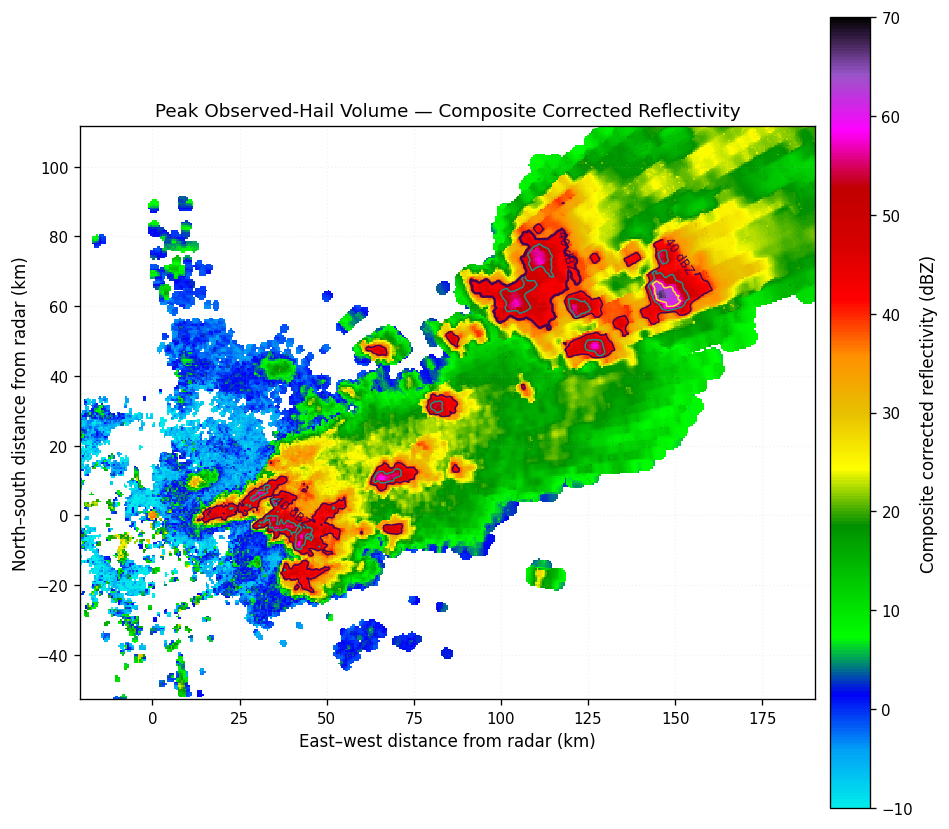

In [17]:
# CELL 17 — Composite reflectivity map

PEAK_COMPOSITE = (
    PEAK_METRICS[
        "composite_ZH_dBZ"
    ]
)

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_COMPOSITE
    ),
    shading="auto",
    cmap=(
        ZH_CMAP
    ),
    vmin=-10.0,
    vmax=70.0,
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Composite corrected reflectivity (dBZ)"
)

core_contour = ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_COMPOSITE,
    levels=[
        40.0,
        50.0,
        60.0,
    ],
    linewidths=0.9,
)

ax.clabel(
    core_contour,
    fmt=lambda value: (
        f"{value:.0f} dBZ"
    ),
    fontsize=7,
)

ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_METRICS[
        "core_mask"
    ].astype(
        float
    ),
    levels=[
        0.5
    ],
    linewidths=1.4,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    "Peak Observed-Hail Volume — Composite Corrected Reflectivity"
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "07_fig01_peak_composite_reflectivity.png"
)

save_figure(
    fig,
    F,
    product="peak composite reflectivity",
    source_file=(
        SELECTED_FILENAME
    ),
    field=(
        FIELD_Z
    ),
    units="dBZ",
)

plt.show()

# 21. Height of maximum reflectivity map

แผนที่นี้ตอบว่า:

```text
maximum ZH ในแต่ละ column อยู่ที่ระดับใด?
```

ตัวอย่างการตีความ:

- maximum ZH ต่ำ → intense core concentrated lower in column
- maximum ZH สูง → elevated intense core

แต่ต้องอ่านร่วมกับ absolute ZH และ echo-top metrics

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig02_peak_height_of_max_reflectivity.png


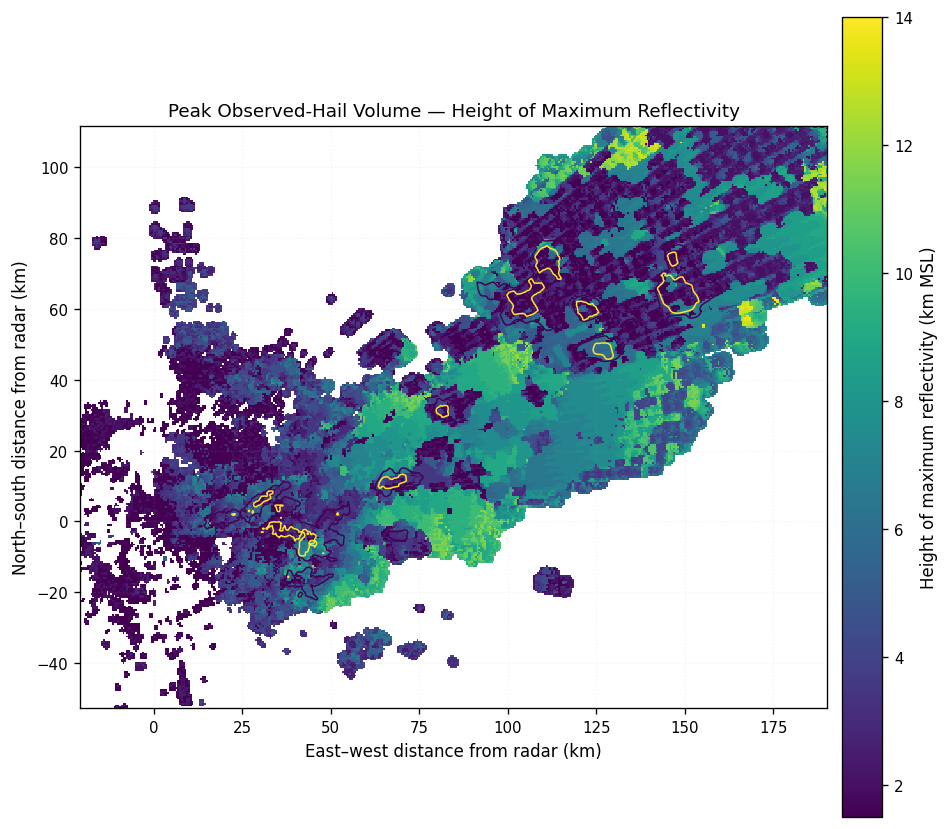

In [18]:
# CELL 18 — Height of maximum ZH map

PEAK_HEIGHT_MAX = (
    PEAK_METRICS[
        "height_of_max_ZH_km_MSL"
    ]
)

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_HEIGHT_MAX
    ),
    shading="auto",
    cmap="viridis",
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Height of maximum reflectivity (km MSL)"
)

ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_COMPOSITE,
    levels=[
        40.0,
        50.0,
    ],
    linewidths=0.9,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    "Peak Observed-Hail Volume — Height of Maximum Reflectivity"
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "07_fig02_peak_height_of_max_reflectivity.png"
)

save_figure(
    fig,
    F,
    product="height of maximum reflectivity",
    source_file=(
        SELECTED_FILENAME
    ),
    units="km MSL",
)

plt.show()

# 22. ET20 / ET30 / ET40 / ET50 maps

แต่ละ threshold จะสร้าง figure แยก เพื่อให้:

- scale อ่านง่าย
- caption ชัด
- นำไปใช้ใน conference/journal ได้โดยไม่ต้องตัด panel ใหม่

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_peak_ET20.png


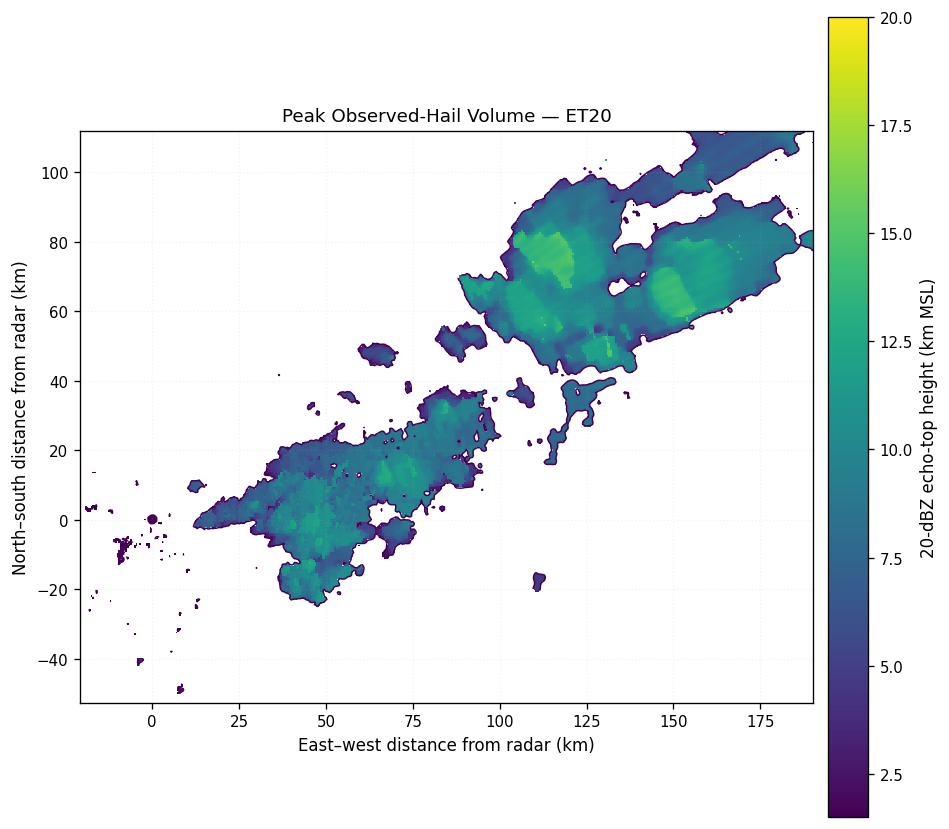

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_peak_ET30.png


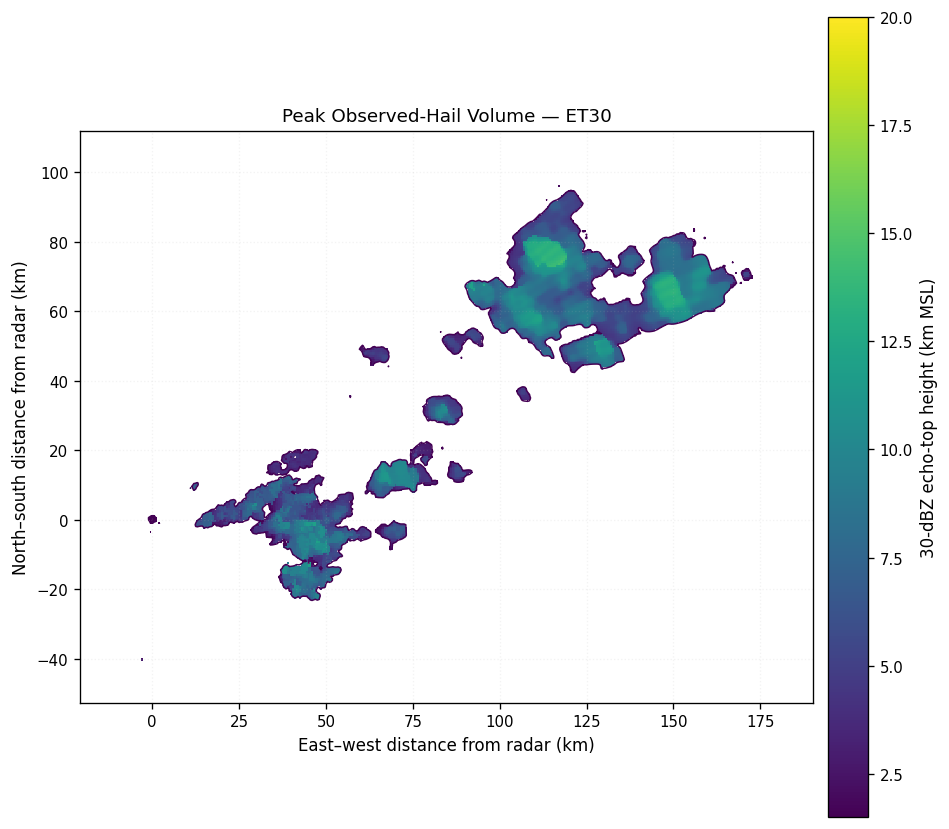

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_peak_ET40.png


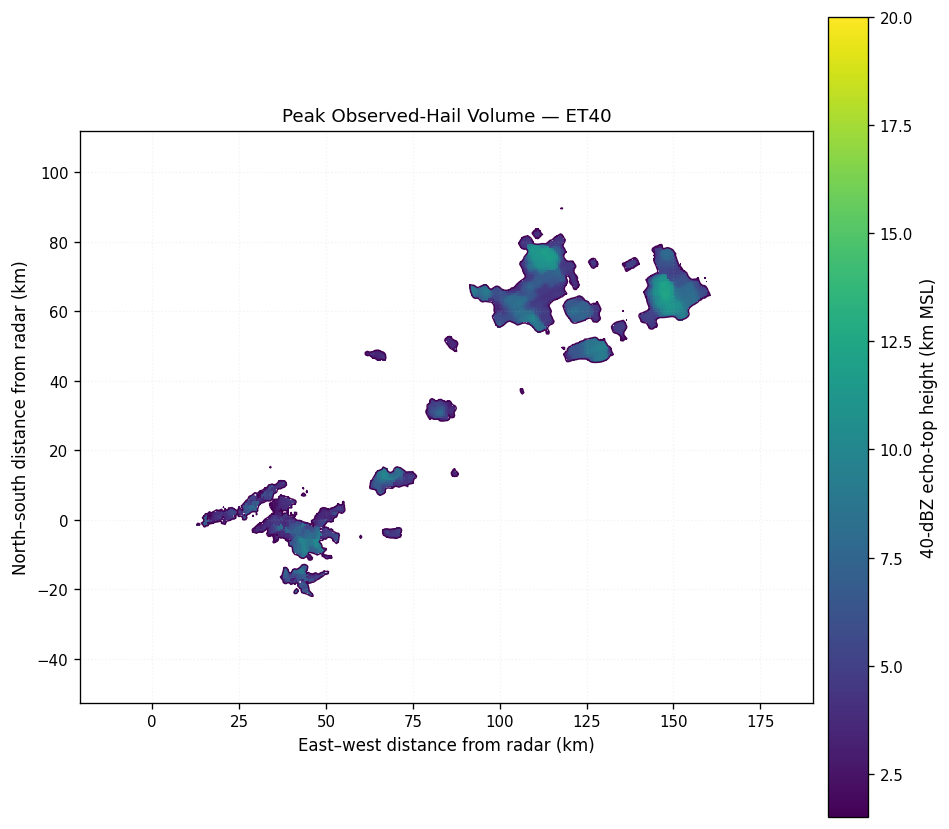

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_peak_ET50.png


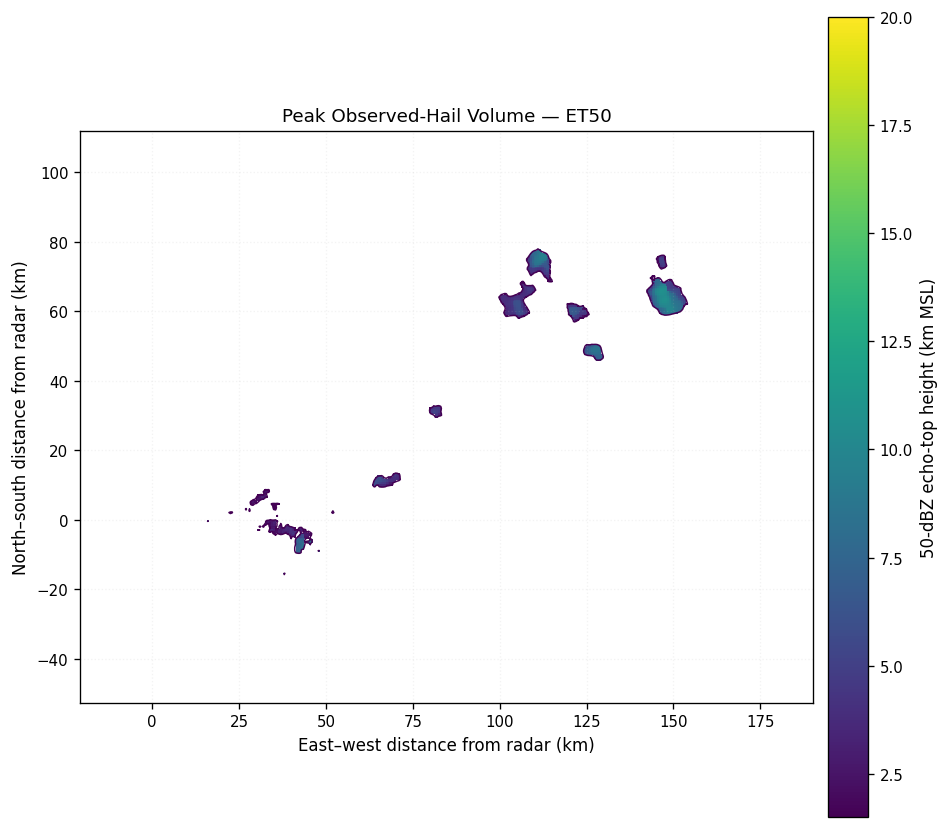

In [19]:
# CELL 19 — Echo-top plotting helper

def plot_echo_top_map(
    threshold_dbz,
):
    product = (
        PEAK_METRICS[
            "threshold_products"
        ][
            threshold_dbz
        ]
    )

    echo_top = (
        product[
            "top_km_MSL"
        ]
    )

    fig = plt.figure(
        figsize=(
            7.8,
            6.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        STORM_X_KM,
        STORM_Y_KM,
        np.ma.masked_invalid(
            echo_top
        ),
        shading="auto",
        cmap="viridis",
        vmin=(
            max(
                0.0,
                STORM_Z_KM_MSL.min()
            )
        ),
        vmax=(
            STORM_Z_KM_MSL.max()
        ),
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        (
            f"{threshold_dbz:.0f}-dBZ echo-top "
            "height (km MSL)"
        )
    )

    ax.contour(
        STORM_X_KM,
        STORM_Y_KM,
        PEAK_COMPOSITE,
        levels=[
            threshold_dbz
        ],
        linewidths=0.9,
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        (
            "Peak Observed-Hail Volume — "
            f"ET{int(threshold_dbz)}"
        )
    )

    ax.grid(
        alpha=0.15,
        linestyle=":",
    )

    output_path = (
        FIGURE_DIR
        / (
            "07_peak_ET"
            f"{int(threshold_dbz)}.png"
        )
    )

    save_figure(
        fig,
        output_path,
        product=(
            f"ET{int(threshold_dbz)}"
        ),
        source_file=(
            SELECTED_FILENAME
        ),
        threshold_dbz=(
            threshold_dbz
        ),
        interpolation=(
            "linear vertical interpolation above highest qualifying grid level"
        ),
        units="km MSL",
    )

    plt.show()


for threshold in (
    ET_THRESHOLDS_DBZ
):
    plot_echo_top_map(
        threshold
    )

# 23. Echo-top censoring summary

หาก ET แตะ grid ceiling:

```text
top_censored = True
```

ค่า ET ใน column นั้นเป็น **lower bound**

Notebook จะรายงานจำนวน censored columns สำหรับแต่ละ threshold

In [20]:
# CELL 20 — Echo-top censoring summary

censor_rows = []

for threshold in (
    ET_THRESHOLDS_DBZ
):
    product = (
        PEAK_METRICS[
            "threshold_products"
        ][
            threshold
        ]
    )

    top = (
        product[
            "top_km_MSL"
        ]
    )

    present = np.isfinite(
        top
    )

    censor_rows.append({
        "threshold_dBZ": (
            threshold
        ),
        "echo_column_count": int(
            present.sum()
        ),
        "top_censored_count": int(
            product[
                "top_censored"
            ][
                present
            ].sum()
        ),
        "top_censored_fraction": (
            float(
                product[
                    "top_censored"
                ][
                    present
                ].mean()
            )
            if present.any()
            else np.nan
        ),
        "maximum_echo_top_km_MSL": (
            float(
                np.nanmax(
                    top
                )
            )
            if present.any()
            else np.nan
        ),
    })


PEAK_ET_CENSORING = pd.DataFrame(
    censor_rows
)

display(
    PEAK_ET_CENSORING
)

PEAK_ET_CENSORING_CSV = (
    OUTPUT_CSV_DIR
    / "07_peak_echo_top_censoring.csv"
)

PEAK_ET_CENSORING.to_csv(
    PEAK_ET_CENSORING_CSV,
    index=False,
)

,threshold_dBZ,echo_column_count,top_censored_count,top_censored_fraction,maximum_echo_top_km_MSL
0,20.0,24766,0,0.0,16.500000
1,30.0,11784,0,0.0,14.537897
2,40.0,5304,0,0.0,12.476756
3,50.0,1256,0,0.0,10.696616


# 24. VIL56 map

VIL56 ใช้:

```text
lower threshold = 18.5 dBZ
upper cap       = 56 dBZ
```

จึงเหมาะกับการสอน standard-like VIL มากกว่า uncapped product

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig07_peak_VIL56.png


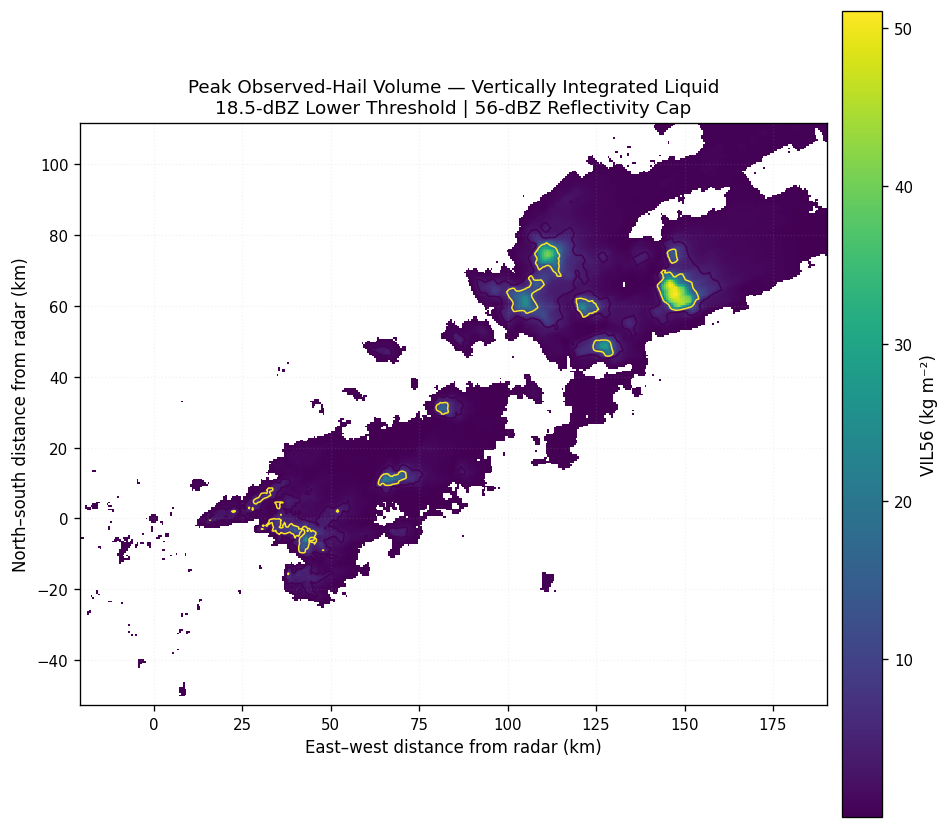

In [21]:
# CELL 21 — VIL56 map

PEAK_VIL56 = (
    PEAK_METRICS[
        "VIL56_kg_m2"
    ]
)

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_VIL56
    ),
    shading="auto",
    cmap="viridis",
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "VIL56 (kg m⁻²)"
)

ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_COMPOSITE,
    levels=[
        40.0,
        50.0,
    ],
    linewidths=0.9,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "Peak Observed-Hail Volume — Vertically Integrated Liquid\n"
        "18.5-dBZ Lower Threshold | 56-dBZ Reflectivity Cap"
    )
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "07_fig07_peak_VIL56.png"
)

save_figure(
    fig,
    F,
    product="VIL56",
    source_file=(
        SELECTED_FILENAME
    ),
    lower_threshold_dbz=(
        VIL_ECHO_THRESHOLD_DBZ
    ),
    upper_cap_dbz=(
        VIL_CAP_DBZ
    ),
    units="kg m-2",
)

plt.show()

# 25. VILD18-ARL map

VILD18-ARL ใช้ VIL56 หารด้วย 18.5-dBZ top height เหนือระดับ radar

ค่าที่ได้ใช้เป็น **relative severe-core diagnostic**

Notebook นี้จะไม่ plot เส้น threshold 3.5 หรือ 4.0 g m⁻³ เป็น hail threshold สำหรับประเทศไทย

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig08_peak_VILD18_ARL.png


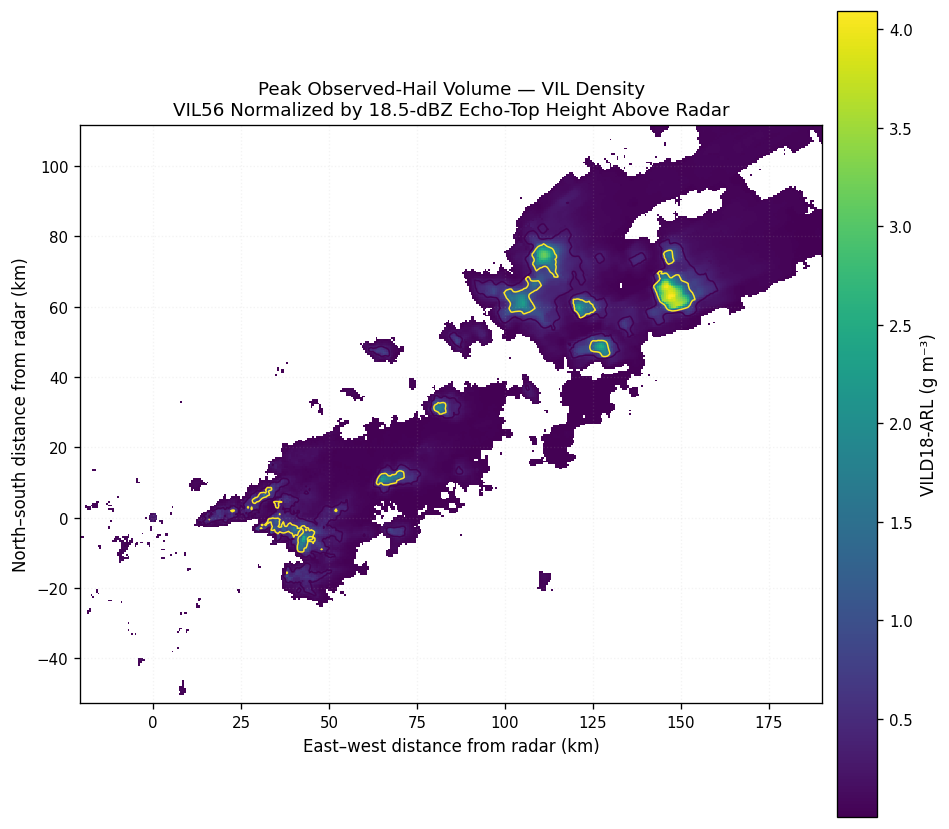

In [22]:
# CELL 22 — VILD18-ARL map

PEAK_VILD_ARL = (
    PEAK_METRICS[
        "VILD18_ARL_g_m3"
    ]
)

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_VILD_ARL
    ),
    shading="auto",
    cmap="viridis",
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "VILD18-ARL (g m⁻³)"
)

ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_COMPOSITE,
    levels=[
        40.0,
        50.0,
    ],
    linewidths=0.9,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "Peak Observed-Hail Volume — VIL Density\n"
        "VIL56 Normalized by 18.5-dBZ Echo-Top Height Above Radar"
    )
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "07_fig08_peak_VILD18_ARL.png"
)

save_figure(
    fig,
    F,
    product="VILD18 ARL",
    source_file=(
        SELECTED_FILENAME
    ),
    interpretation=(
        "Relative severe-core diagnostic; no imported hail threshold applied."
    ),
    units="g m-3",
)

plt.show()

# 26. VIL cap sensitivity

สำหรับ hail-producing storm ควรตรวจว่า 56-dBZ cap มีผลต่อ VIL มากเพียงใด

คำนวณ:

$$
\Delta VIL
=
VIL_{uncapped}
-
VIL_{56}
$$

บริเวณที่ $\Delta VIL$ สูง คือบริเวณที่ very high reflectivity มีอิทธิพลต่อ VIL มาก

In [23]:
# CELL 23 — VIL cap-sensitivity summary

PEAK_VIL_UNCAPPED = (
    PEAK_METRICS[
        "VIL_uncapped_kg_m2"
    ]
)

VIL_CAP_DIFFERENCE = (
    PEAK_VIL_UNCAPPED
    - PEAK_VIL56
)

valid_vil = (
    np.isfinite(
        PEAK_VIL56
    )
    & np.isfinite(
        PEAK_VIL_UNCAPPED
    )
)

VIL_CAP_SENSITIVITY = pd.DataFrame({
    "metric": [
        "common_valid_pixels",
        "maximum_VIL56_kg_m2",
        "maximum_uncapped_VIL_kg_m2",
        "maximum_uncapped_minus_capped_kg_m2",
        "median_uncapped_minus_capped_kg_m2",
        "P95_uncapped_minus_capped_kg_m2",
    ],
    "value": [
        int(
            valid_vil.sum()
        ),
        (
            float(
                np.nanmax(
                    PEAK_VIL56[
                        valid_vil
                    ]
                )
            )
            if valid_vil.any()
            else np.nan
        ),
        (
            float(
                np.nanmax(
                    PEAK_VIL_UNCAPPED[
                        valid_vil
                    ]
                )
            )
            if valid_vil.any()
            else np.nan
        ),
        (
            float(
                np.nanmax(
                    VIL_CAP_DIFFERENCE[
                        valid_vil
                    ]
                )
            )
            if valid_vil.any()
            else np.nan
        ),
        (
            float(
                np.nanmedian(
                    VIL_CAP_DIFFERENCE[
                        valid_vil
                    ]
                )
            )
            if valid_vil.any()
            else np.nan
        ),
        (
            float(
                np.nanpercentile(
                    VIL_CAP_DIFFERENCE[
                        valid_vil
                    ],
                    95,
                )
            )
            if valid_vil.any()
            else np.nan
        ),
    ],
})

display(
    VIL_CAP_SENSITIVITY
)

VIL_CAP_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "07_peak_VIL_cap_sensitivity.csv"
)

VIL_CAP_SENSITIVITY.to_csv(
    VIL_CAP_SENSITIVITY_CSV,
    index=False,
)

,metric,value
0,common_valid_pixels,28724.000000
1,maximum_VIL56_kg_m2,51.070014
2,maximum_uncapped_VIL_kg_m2,131.040547
3,maximum_uncapped_minus_capped_kg_m2,81.694147
4,median_uncapped_minus_capped_kg_m2,0.000000
5,P95_uncapped_minus_capped_kg_m2,0.000000


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig09_peak_VIL_cap_sensitivity.png


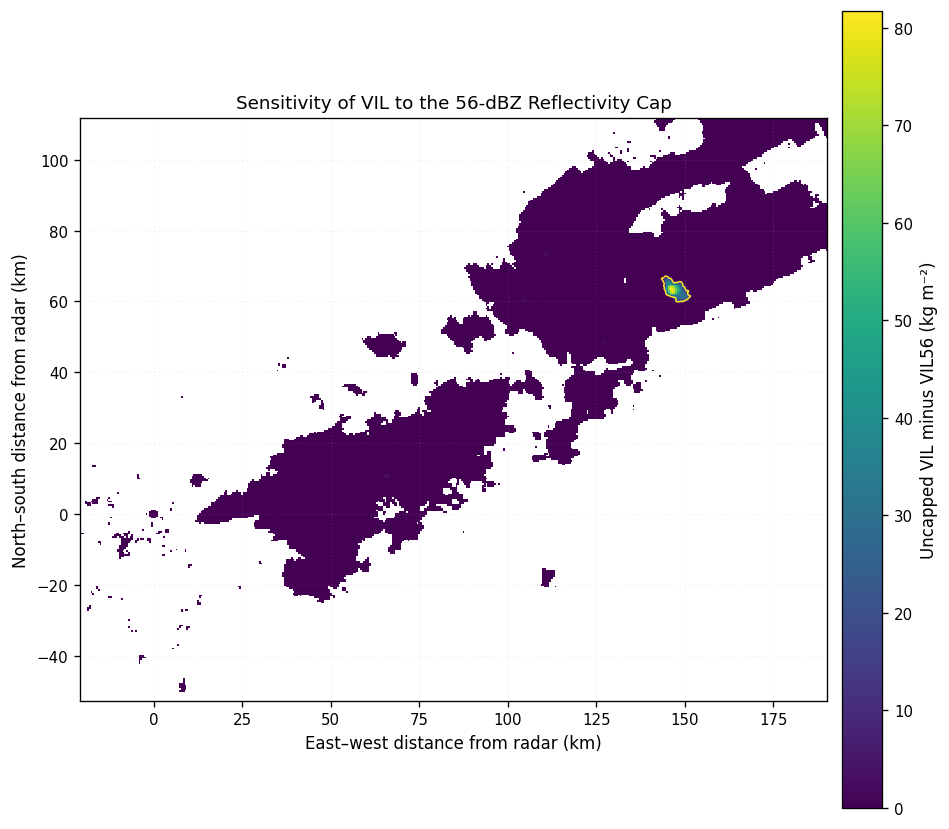

In [24]:
# CELL 24 — VIL cap-difference map

fig = plt.figure(
    figsize=(
        7.8,
        6.8,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        VIL_CAP_DIFFERENCE
    ),
    shading="auto",
    cmap="viridis",
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Uncapped VIL minus VIL56 (kg m⁻²)"
)

ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_COMPOSITE,
    levels=[
        50.0,
        60.0,
    ],
    linewidths=0.9,
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    "Sensitivity of VIL to the 56-dBZ Reflectivity Cap"
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "07_fig09_peak_VIL_cap_sensitivity.png"
)

save_figure(
    fig,
    F,
    product="VIL cap sensitivity",
    source_file=(
        SELECTED_FILENAME
    ),
    units="kg m-2",
)

plt.show()

# 27. Severe-core footprint และ echo volume ของ peak volume

Main severe core ถูกนิยามจาก largest connected footprint ที่:

```text
Composite ZH ≥ 40 dBZ
```

จากนั้นคำนวณ:

- core area
- 50-dBZ footprint area
- 40-dBZ echo volume
- 50-dBZ echo volume
- centroid
- maximum ET40 / ET50
- maximum VIL / VILD

นี่ช่วยเปลี่ยนจาก pixel-based analysis ไปสู่ storm-core object analysis

In [25]:
# CELL 25 — Peak severe-core object summary

PEAK_CORE_SUMMARY = pd.DataFrame(
    [
        {
            "source_file": (
                SELECTED_FILENAME
            ),
            **PEAK_SCALAR,
        }
    ]
)

display(
    PEAK_CORE_SUMMARY
)

PEAK_CORE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "07_peak_core_object_summary.csv"
)

PEAK_CORE_SUMMARY.to_csv(
    PEAK_CORE_SUMMARY_CSV,
    index=False,
)

,source_file,core_threshold_dBZ,n_connected_objects,core_pixel_count,core_area_km2,intense_50dBZ_footprint_area_km2,core_centroid_x_km,core_centroid_y_km,maximum_ZH_dBZ,height_of_core_maximum_ZH_km_MSL,...,maximum_VIL_uncapped_kg_m2,maximum_VILD18_ARL_g_m3,maximum_VILD18_depth_g_m3,echo_volume_ge_40dBZ_km3,echo_volume_ge_50dBZ_km3,maximum_ET20_km_MSL,maximum_ET30_km_MSL,maximum_ET40_km_MSL,maximum_ET50_km_MSL,core_touches_grid_edge
0,20230318111202.uf.gz,40.0,33,1640,410.0,94.25,109.422866,67.08628,57.458981,1.5,...,40.626102,3.171516,3.256183,2047.75,347.25,16.5,14.537897,11.840629,9.726201,False


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig10_peak_largest_40dBZ_core.png


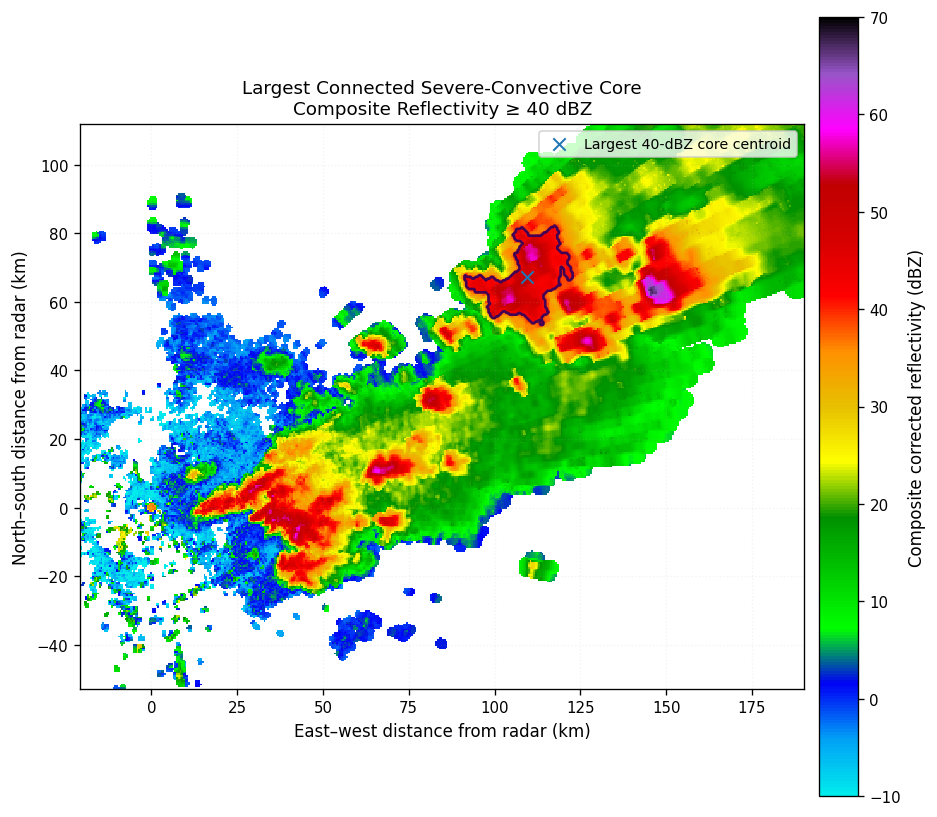

In [26]:
# CELL 26 — Peak core-footprint figure

fig = plt.figure(
    figsize=(
        7.7,
        6.7,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    STORM_X_KM,
    STORM_Y_KM,
    np.ma.masked_invalid(
        PEAK_COMPOSITE
    ),
    shading="auto",
    cmap=(
        ZH_CMAP
    ),
    vmin=-10.0,
    vmax=70.0,
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Composite corrected reflectivity (dBZ)"
)

ax.contour(
    STORM_X_KM,
    STORM_Y_KM,
    PEAK_METRICS[
        "core_mask"
    ].astype(
        float
    ),
    levels=[
        0.5
    ],
    linewidths=1.6,
)

ax.scatter(
    PEAK_SCALAR[
        "core_centroid_x_km"
    ],
    PEAK_SCALAR[
        "core_centroid_y_km"
    ],
    marker="x",
    s=55,
    label="Largest 40-dBZ core centroid",
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_title(
    (
        "Largest Connected Severe-Convective Core\n"
        "Composite Reflectivity ≥ 40 dBZ"
    )
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "07_fig10_peak_largest_40dBZ_core.png"
)

save_figure(
    fig,
    F,
    product="largest 40-dBZ severe core",
    source_file=(
        SELECTED_FILENAME
    ),
    core_threshold_dbz=(
        CORE_FOOTPRINT_THRESHOLD_DBZ
    ),
    units="dBZ",
)

plt.show()

# 28. Export peak severe products เป็น GeoTIFF

เพื่อให้ severe-storm diagnostics นำไปใช้ต่อใน GIS ได้ จะ export:

```text
Composite ZH
Height of maximum ZH
ET40
ET50
VIL56
VILD18-ARL
```

CRS ใช้ radar-centered AEQD เหมือน Cartesian grid

> GeoTIFF นี้เป็นผลจาก interpolated 3-D radar grid ไม่ใช่ native polar observation

In [27]:
# CELL 27 — Storm-grid AEQD raster geometry

PYART_SPHERE_RADIUS_M = 6370997.0

NATIVE_AEQD_CRS = rasterio.crs.CRS.from_proj4(
    (
        f"+proj=aeqd "
        f"+lat_0={RADAR_LAT} "
        f"+lon_0={RADAR_LON} "
        f"+R={PYART_SPHERE_RADIUS_M} "
        "+units=m "
        "+no_defs"
    )
)

storm_x_m = (
    STORM_X_KM
    * 1000.0
)

storm_y_m = (
    STORM_Y_KM
    * 1000.0
)

storm_dx_m = (
    STORM_DX_KM
    * 1000.0
)

storm_dy_m = (
    STORM_DY_KM
    * 1000.0
)

storm_west = float(
    storm_x_m.min()
    - storm_dx_m
    / 2.0
)

storm_north = float(
    storm_y_m.max()
    + storm_dy_m
    / 2.0
)

STORM_TRANSFORM = from_origin(
    storm_west,
    storm_north,
    storm_dx_m,
    storm_dy_m,
)

print(
    "Peak severe-product GeoTIFF CRS:",
    NATIVE_AEQD_CRS,
)

Peak severe-product GeoTIFF CRS: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370997,0]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["latitude_of_center",17.7982074652778],PARAMETER["longitude_of_center",98.4323263888889],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [28]:
# CELL 28 — GeoTIFF writer

def write_peak_metric_geotiff(
    array_2d,
    *,
    output_path,
    product,
    units,
):
    output_path = Path(
        output_path
    )

    array = np.asarray(
        array_2d,
        dtype=float,
    )

    raster_array = np.flipud(
        np.where(
            np.isfinite(
                array
            ),
            array,
            GEOTIFF_NODATA,
        )
    ).astype(
        "float32"
    )

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=raster_array.shape[
            0
        ],
        width=raster_array.shape[
            1
        ],
        count=1,
        dtype="float32",
        crs=(
            NATIVE_AEQD_CRS
        ),
        transform=(
            STORM_TRANSFORM
        ),
        nodata=(
            GEOTIFF_NODATA
        ),
        compress="deflate",
    ) as dst:

        dst.write(
            raster_array,
            1,
        )

        dst.update_tags(
            event_id=str(
                ACTIVE_EVENT.get(
                    "event_id"
                )
            ),
            source_file=(
                SELECTED_FILENAME
            ),
            product=(
                product
            ),
            units=(
                units
            ),
            source_grid=(
                STORM_GRID_NETCDF.name
            ),
            interpretation=(
                "Derived from interpolated 3-D Cartesian radar reflectivity."
            ),
        )

    return (
        output_path
    )

In [29]:
# CELL 29 — Export peak severe-product GeoTIFFs

PEAK_GEOTIFF_PRODUCTS = {
    "composite_ZH": {
        "array": (
            PEAK_COMPOSITE
        ),
        "units": "dBZ",
    },
    "height_of_max_ZH": {
        "array": (
            PEAK_HEIGHT_MAX
        ),
        "units": "km MSL",
    },
    "ET40": {
        "array": (
            PEAK_METRICS[
                "threshold_products"
            ][
                40.0
            ][
                "top_km_MSL"
            ]
        ),
        "units": "km MSL",
    },
    "ET50": {
        "array": (
            PEAK_METRICS[
                "threshold_products"
            ][
                50.0
            ][
                "top_km_MSL"
            ]
        ),
        "units": "km MSL",
    },
    "VIL56": {
        "array": (
            PEAK_VIL56
        ),
        "units": "kg m-2",
    },
    "VILD18_ARL": {
        "array": (
            PEAK_VILD_ARL
        ),
        "units": "g m-3",
    },
}

peak_geotiff_rows = []

for product_name, product_info in (
    PEAK_GEOTIFF_PRODUCTS.items()
):
    path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "07_peak_"
            f"{product_name}_native_AEQD.tif"
        )
    )

    write_peak_metric_geotiff(
        product_info[
            "array"
        ],
        output_path=(
            path
        ),
        product=(
            product_name
        ),
        units=(
            product_info[
                "units"
            ]
        ),
    )

    peak_geotiff_rows.append({
        "product": (
            product_name
        ),
        "units": (
            product_info[
                "units"
            ]
        ),
        "path": str(
            path
        ),
    })


PEAK_GEOTIFF_MANIFEST = pd.DataFrame(
    peak_geotiff_rows
)

display(
    PEAK_GEOTIFF_MANIFEST
)

PEAK_GEOTIFF_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "07_peak_GeoTIFF_manifest.csv"
)

PEAK_GEOTIFF_MANIFEST.to_csv(
    PEAK_GEOTIFF_MANIFEST_CSV,
    index=False,
)

,product,units,path
0,composite_ZH,dBZ,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
1,height_of_max_ZH,km MSL,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
2,ET40,km MSL,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
3,ET50,km MSL,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
4,VIL56,kg m-2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
5,VILD18_ARL,g m-3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...


In [30]:
# CELL 30 — Reopen and validate peak GeoTIFFs

validation_rows = []

for _, row in (
    PEAK_GEOTIFF_MANIFEST.iterrows()
):
    path = Path(
        row[
            "path"
        ]
    )

    with rasterio.open(
        path
    ) as src:

        data = src.read(
            1,
            masked=True,
        )

        values = data.compressed()

        validation_rows.append({
            "product": (
                row[
                    "product"
                ]
            ),
            "path": str(
                path
            ),
            "crs": str(
                src.crs
            ),
            "width": (
                src.width
            ),
            "height": (
                src.height
            ),
            "valid_pixel_count": int(
                data.count()
            ),
            "minimum": (
                float(
                    data.min()
                )
                if data.count()
                else np.nan
            ),
            "maximum": (
                float(
                    data.max()
                )
                if data.count()
                else np.nan
            ),
            "negative_value_count": int(
                (
                    values
                    < 0.0
                ).sum()
            )
            if row[
                "product"
            ] not in [
                "composite_ZH"
            ]
            else np.nan,
        })


PEAK_GEOTIFF_VALIDATION = pd.DataFrame(
    validation_rows
)

display(
    PEAK_GEOTIFF_VALIDATION
)

PEAK_GEOTIFF_VALIDATION_CSV = (
    OUTPUT_CSV_DIR
    / "07_peak_GeoTIFF_validation.csv"
)

PEAK_GEOTIFF_VALIDATION.to_csv(
    PEAK_GEOTIFF_VALIDATION_CSV,
    index=False,
)

,product,path,crs,width,height,valid_pixel_count,minimum,maximum,negative_value_count
0,composite_ZH,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,62823,-18.000000,67.324150,NaN
1,height_of_max_ZH,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,62823,1.500000,14.000000,0.0
2,ET40,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,5304,1.500000,12.476756,0.0
3,ET50,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,1256,1.500000,10.696615,0.0
4,VIL56,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,28724,0.009809,51.070015,0.0
5,VILD18_ARL,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",422,329,28724,0.001659,4.092614,0.0


# 29. จาก peak volume ไปสู่ storm lifecycle

Peak volume บอกโครงสร้าง ณ เวลาหนึ่ง

แต่ severe storm เป็นระบบที่เปลี่ยนตามเวลา

Notebook 07 จึงประมวลผล radar volumes ทั้ง 10 scans เพื่อสร้าง:

```text
11:06
11:12
11:18
...
12:00 UTC
```

แล้วติดตามตัวชี้วัด:

```text
Max ZH
Height of max ZH
ET40
ET50
VIL56
VILD18
40-dBZ area
50-dBZ area
40-dBZ volume
50-dBZ volume
```

ขั้นนี้ทำให้เราศึกษา:

```text
growth
→ mature
→ decay
```

# 30. Dynamic storm-centered grid

หากใช้ fixed storm box จาก peak volume กับทุกเวลา พายุอาจเคลื่อนออกจาก box

Notebook จึงทำ:

```text
lowest-sweep ZH
      ↓
search within event sector
      ↓
find ≥40 dBZ gates
      ↓
robust median centroid
      ↓
center a 3-D grid around that centroid
```

หากไม่พบ 40 dBZ จะ fallback:

```text
35 dBZ
30 dBZ
```

หากยังไม่พบ จะใช้ strong-echo reference จาก Notebook 03

นี่เป็น **teaching storm-following approach**

ยังไม่ใช่ formal storm-object tracking algorithm

In [31]:
# CELL 31 — Parse lifecycle gridding parameters from Notebook 03

WEIGHTING_FUNCTION = str(
    grid_config_lookup[
        "weighting_function"
    ]
)

ROI_FUNCTION = str(
    grid_config_lookup[
        "roi_function"
    ]
)

MIN_RADIUS_M = float(
    grid_config_lookup[
        "minimum_roi_m"
    ]
)

ROI_NB = float(
    grid_config_lookup[
        "roi_nb"
    ]
)

ROI_BSP = float(
    grid_config_lookup[
        "roi_bsp"
    ]
)

ROI_H_FACTOR = ast.literal_eval(
    str(
        grid_config_lookup[
            "roi_h_factor"
        ]
    )
)

RADAR_FILES = list(
    COURSE_CONFIG[
        "radar"
    ][
        "source_files"
    ]
)

print(
    "Radar volumes:",
    len(
        RADAR_FILES
    ),
)

print(
    "Weighting:",
    WEIGHTING_FUNCTION,
)

print(
    "ROI:",
    ROI_FUNCTION,
)

Radar volumes: 10
Weighting: Barnes2
ROI: dist_beam


In [32]:
# CELL 32 — Robust radar reader

RADAR_CACHE = (
    Path(
        tempfile.gettempdir()
    )
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(
    path,
):
    path = Path(
        path
    )

    try:
        return pyart.io.read(
            str(
                path
            )
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix(
                ""
            ).name
        )

        if not unpacked.exists():
            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:
                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(
                    unpacked
                )
            )

        except Exception as unpacked_error:
            raise RuntimeError(
                f"อ่านไฟล์ {path.name} ไม่สำเร็จ "
                f"(compressed={direct_error!r}; "
                f"unpacked={unpacked_error!r})"
            ) from unpacked_error

In [33]:
# CELL 33 — Internal UTC time helper

LOCAL_TIMEZONE = COURSE_CONFIG[
    "time"
][
    "local_timezone"
]


def radar_datetime_utc(
    radar_object,
):
    units = radar_object.time.get(
        "units"
    )

    if units is None:
        return pd.NaT

    units_text = str(
        units
    ).upper()

    if not (
        "Z" in units_text
        or "UTC" in units_text
        or "+00:00" in units_text
    ):
        raise ValueError(
            "Radar time units ไม่ได้ระบุ UTC อย่างชัดเจน"
        )

    dt = num2date(
        radar_object.time[
            "data"
        ][0],
        units=units,
        calendar=radar_object.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    timestamp = pd.Timestamp(
        dt
    )

    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize(
            "UTC"
        )

    else:
        timestamp = timestamp.tz_convert(
            "UTC"
        )

    return timestamp

In [34]:
# CELL 34 — Angular difference helper

def angular_difference_deg(
    angle,
    target,
):
    return np.abs(
        (
            (
                np.asarray(
                    angle,
                    dtype=float,
                )
                - float(
                    target
                )
                + 180.0
            )
            % 360.0
        )
        - 180.0
    )

In [35]:
# CELL 35 — Locate the main intense core from the lowest sweep

def locate_native_core_center(
    radar_object,
    *,
    field_name,
    target_azimuth_deg,
    reference_range_km,
):
    sweep = 0

    start_ray = int(
        radar_object.sweep_start_ray_index[
            "data"
        ][
            sweep
        ]
    )

    end_ray = int(
        radar_object.sweep_end_ray_index[
            "data"
        ][
            sweep
        ]
    )

    zh = np.ma.asarray(
        radar_object.get_field(
            sweep,
            field_name,
            copy=True,
        )
    ).filled(
        np.nan
    )

    gate_x_km = (
        np.asarray(
            radar_object.gate_x[
                "data"
            ][
                start_ray:
                end_ray
                + 1
            ],
            dtype=float,
        )
        / 1000.0
    )

    gate_y_km = (
        np.asarray(
            radar_object.gate_y[
                "data"
            ][
                start_ray:
                end_ray
                + 1
            ],
            dtype=float,
        )
        / 1000.0
    )

    horizontal_range_km = np.sqrt(
        gate_x_km**2
        + gate_y_km**2
    )

    ray_azimuth = np.asarray(
        radar_object.azimuth[
            "data"
        ][
            start_ray:
            end_ray
            + 1
        ],
        dtype=float,
    )

    azimuth_2d = np.repeat(
        ray_azimuth[
            :,
            None
        ],
        zh.shape[
            1
        ],
        axis=1,
    )

    sector_ok = (
        angular_difference_deg(
            azimuth_2d,
            target_azimuth_deg,
        )
        <= CORE_SEARCH_HALF_ANGLE_DEG
    )

    range_ok = (
        (
            horizontal_range_km
            >= CORE_SEARCH_MIN_RANGE_KM
        )
        & (
            horizontal_range_km
            <= CORE_SEARCH_MAX_RANGE_KM
        )
    )

    finite = np.isfinite(
        zh
    )

    for threshold in (
        CORE_SEARCH_THRESHOLDS_DBZ
    ):
        hits = (
            finite
            & sector_ok
            & range_ok
            & (
                zh
                >= threshold
            )
        )

        if hits.any():
            center_x = float(
                np.nanmedian(
                    gate_x_km[
                        hits
                    ]
                )
            )

            center_y = float(
                np.nanmedian(
                    gate_y_km[
                        hits
                    ]
                )
            )

            return {
                "center_x_km": (
                    center_x
                ),
                "center_y_km": (
                    center_y
                ),
                "threshold_used_dBZ": (
                    threshold
                ),
                "n_native_gates": int(
                    hits.sum()
                ),
                "fallback_used": False,
            }

    theta = np.deg2rad(
        target_azimuth_deg
    )

    fallback_x = (
        reference_range_km
        * np.sin(
            theta
        )
    )

    fallback_y = (
        reference_range_km
        * np.cos(
            theta
        )
    )

    return {
        "center_x_km": float(
            fallback_x
        ),
        "center_y_km": float(
            fallback_y
        ),
        "threshold_used_dBZ": np.nan,
        "n_native_gates": 0,
        "fallback_used": True,
    }

In [36]:
# CELL 36 — Lifecycle 3-D gridding helper

def make_reflectivity_gatefilter(
    radar_object,
):
    gatefilter = pyart.filters.GateFilter(
        radar_object
    )

    gatefilter.exclude_invalid(
        FIELD_Z
    )

    gatefilter.exclude_masked(
        FIELD_Z
    )

    try:
        gatefilter.exclude_transition()
    except Exception:
        pass

    return gatefilter


def build_lifecycle_grid(
    radar_object,
    *,
    center_x_km,
    center_y_km,
):
    gatefilter = (
        make_reflectivity_gatefilter(
            radar_object
        )
    )

    nx = int(
        round(
            2.0
            * LIFECYCLE_HALF_WIDTH_KM
            / LIFECYCLE_GRID_DX_KM
        )
    ) + 1

    ny = nx

    nz = len(
        STORM_Z_KM_MSL
    )

    x_limits_m = (
        (
            center_x_km
            - LIFECYCLE_HALF_WIDTH_KM
        )
        * 1000.0,
        (
            center_x_km
            + LIFECYCLE_HALF_WIDTH_KM
        )
        * 1000.0,
    )

    y_limits_m = (
        (
            center_y_km
            - LIFECYCLE_HALF_WIDTH_KM
        )
        * 1000.0,
        (
            center_y_km
            + LIFECYCLE_HALF_WIDTH_KM
        )
        * 1000.0,
    )

    z_limits_m = (
        STORM_Z_KM_MSL.min()
        * 1000.0,
        STORM_Z_KM_MSL.max()
        * 1000.0,
    )

    start = time.perf_counter()

    grid = pyart.map.grid_from_radars(
        (
            radar_object,
        ),
        grid_shape=(
            nz,
            ny,
            nx,
        ),
        grid_limits=(
            z_limits_m,
            y_limits_m,
            x_limits_m,
        ),
        grid_origin=(
            RADAR_LAT,
            RADAR_LON,
        ),
        grid_origin_alt=0.0,
        fields=[
            FIELD_Z
        ],
        gatefilters=(
            gatefilter
        ),
        gridding_algo=(
            "map_gates_to_grid"
        ),
        weighting_function=(
            WEIGHTING_FUNCTION
        ),
        roi_func=(
            ROI_FUNCTION
        ),
        min_radius=(
            MIN_RADIUS_M
        ),
        nb=(
            ROI_NB
        ),
        bsp=(
            ROI_BSP
        ),
        h_factor=(
            ROI_H_FACTOR
        ),
        map_roi=False,
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return (
        grid,
        elapsed,
    )

# 31. ประมวลผลทั้ง 10 volumes

สำหรับแต่ละเวลา:

1. อ่าน UF
2. อ่าน internal UTC
3. หา main core center จาก lowest sweep
4. สร้าง dynamic 3-D grid
5. คำนวณ severe metrics
6. ตรวจ core-edge contact
7. export scalar lifecycle record
8. ลบ Grid object ออกจาก memory ก่อนอ่านไฟล์ถัดไป

In [37]:
# CELL 37 — Process ten-volume severe-storm lifecycle

lifecycle_rows = []

for file_index, filename in enumerate(
    RADAR_FILES,
    start=1,
):
    print(
        f"[{file_index:02d}/{len(RADAR_FILES)}] "
        f"{filename}"
    )

    radar_i = read_radar_file(
        RADAR_DIR
        / filename
    )

    if FIELD_Z not in radar_i.fields:
        raise KeyError(
            f"{filename}: ไม่พบ {FIELD_Z}"
        )

    time_utc_i = radar_datetime_utc(
        radar_i
    )

    center_info = (
        locate_native_core_center(
            radar_i,
            field_name=(
                FIELD_Z
            ),
            target_azimuth_deg=(
                TARGET_AZIMUTH_DEG
            ),
            reference_range_km=(
                CORE_REFERENCE_RANGE_KM
            ),
        )
    )

    grid_i, elapsed_i = (
        build_lifecycle_grid(
            radar_i,
            center_x_km=(
                center_info[
                    "center_x_km"
                ]
            ),
            center_y_km=(
                center_info[
                    "center_y_km"
                ]
            ),
        )
    )

    x_i = (
        np.asarray(
            grid_i.x[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    y_i = (
        np.asarray(
            grid_i.y[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    z_i = (
        np.asarray(
            grid_i.z[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    field_i = np.ma.asarray(
        grid_i.fields[
            FIELD_Z
        ][
            "data"
        ]
    )

    metrics_i = (
        severe_metrics_from_grid(
            field_i,
            x_i,
            y_i,
            z_i,
            radar_altitude_km_MSL=(
                RADAR_ALTITUDE_KM_MSL
            ),
            core_threshold_dbz=(
                CORE_FOOTPRINT_THRESHOLD_DBZ
            ),
        )
    )

    scalar_i = (
        metrics_i[
            "scalar"
        ]
    )

    lifecycle_rows.append({
        "filename": (
            filename
        ),
        "time_UTC": (
            time_utc_i
        ),
        "time_ICT": (
            time_utc_i.tz_convert(
                LOCAL_TIMEZONE
            )
        ),
        "native_core_center_x_km": (
            center_info[
                "center_x_km"
            ]
        ),
        "native_core_center_y_km": (
            center_info[
                "center_y_km"
            ]
        ),
        "native_core_search_threshold_dBZ": (
            center_info[
                "threshold_used_dBZ"
            ]
        ),
        "native_core_search_gate_count": (
            center_info[
                "n_native_gates"
            ]
        ),
        "native_core_search_fallback": (
            center_info[
                "fallback_used"
            ]
        ),
        "dynamic_grid_elapsed_seconds": (
            elapsed_i
        ),
        **scalar_i,
    })

    del metrics_i
    del field_i
    del grid_i
    del radar_i

    gc.collect()


LIFECYCLE_METRICS = pd.DataFrame(
    lifecycle_rows
).sort_values(
    "time_UTC"
).reset_index(
    drop=True
)

display(
    LIFECYCLE_METRICS
)

LIFECYCLE_METRICS_CSV = (
    OUTPUT_CSV_DIR
    / "07_severe_storm_lifecycle_metrics.csv"
)

LIFECYCLE_METRICS.to_csv(
    LIFECYCLE_METRICS_CSV,
    index=False,
)

[01/10] 20230318110609.uf.gz
[02/10] 20230318111202.uf.gz
[03/10] 20230318111802.uf.gz
[04/10] 20230318112402.uf.gz
[05/10] 20230318113002.uf.gz
[06/10] 20230318113602.uf.gz
[07/10] 20230318114202.uf.gz
[08/10] 20230318114802.uf.gz
[09/10] 20230318115402.uf.gz
[10/10] 20230318120002.uf.gz


,filename,time_UTC,time_ICT,native_core_center_x_km,native_core_center_y_km,native_core_search_threshold_dBZ,native_core_search_gate_count,native_core_search_fallback,dynamic_grid_elapsed_seconds,core_threshold_dBZ,...,maximum_VIL_uncapped_kg_m2,maximum_VILD18_ARL_g_m3,maximum_VILD18_depth_g_m3,echo_volume_ge_40dBZ_km3,echo_volume_ge_50dBZ_km3,maximum_ET20_km_MSL,maximum_ET30_km_MSL,maximum_ET40_km_MSL,maximum_ET50_km_MSL,core_touches_grid_edge
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,106.187461,60.992355,40.0,759,False,0.872845,40.0,...,47.620196,3.285499,3.393153,1959.5,440.0,17.000000,16.000000,11.389129,9.319166,False
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,110.488250,59.817367,40.0,931,False,1.121329,40.0,...,40.297847,3.147801,3.230423,2060.5,346.0,15.500000,14.508606,11.815581,9.659167,False
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,112.663703,59.842338,40.0,1080,False,0.835163,40.0,...,40.770522,2.810506,2.897577,3620.5,600.0,15.500000,13.644831,11.141554,7.351337,False
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,114.058004,58.583176,40.0,1134,False,0.827625,40.0,...,50.534206,3.306746,3.406704,3050.0,564.5,15.500000,15.500000,10.390952,8.834447,False
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,106.796477,55.296469,40.0,1055,False,0.814215,40.0,...,36.431023,3.042490,3.160812,2532.0,511.5,16.000000,16.000000,10.378588,9.174979,False
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,2023-03-18 18:36:02+07:00,101.371398,49.988504,40.0,997,False,1.183301,40.0,...,31.892115,2.896857,3.000809,2228.0,558.0,15.000000,12.899505,9.431610,7.007449,False
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,2023-03-18 18:42:02+07:00,97.010430,48.417215,40.0,1014,False,1.092218,40.0,...,34.786997,3.190773,3.307088,2125.5,281.0,17.500000,13.698319,10.063929,7.454358,False
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,2023-03-18 18:48:02+07:00,99.345352,48.423793,40.0,931,False,1.634316,40.0,...,30.478021,2.850773,2.953218,1821.0,298.0,14.133379,11.144964,8.968264,7.479322,False
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,108.772922,47.064215,40.0,1000,False,0.893238,40.0,...,52.214022,3.443765,3.555375,1701.0,276.0,14.500000,12.539674,10.573615,9.028258,False
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,110.817164,43.250840,40.0,1039,False,0.872757,40.0,...,45.464056,3.538617,3.769429,2146.5,478.5,15.500000,14.500000,10.634607,8.399517,False


# 32. ตรวจ dynamic-grid edge contact

ถ้า largest 40-dBZ core แตะขอบ grid:

```text
core_touches_grid_edge = True
```

metrics เช่น:

- core area
- echo volume
- footprint area

อาจต่ำกว่าความจริง เพราะ object อาจถูกตัด

จึงต้องรายงาน edge contact ก่อนตีความ lifecycle

In [38]:
# CELL 38 — Dynamic-grid QC summary

EDGE_CONTACT_COUNT = int(
    LIFECYCLE_METRICS[
        "core_touches_grid_edge"
    ].sum()
)

FALLBACK_CENTER_COUNT = int(
    LIFECYCLE_METRICS[
        "native_core_search_fallback"
    ].sum()
)

LIFECYCLE_GRID_QC = pd.DataFrame({
    "metric": [
        "n_volumes",
        "core_edge_contact_count",
        "core_search_fallback_count",
        "maximum_gridding_time_seconds",
        "median_gridding_time_seconds",
    ],
    "value": [
        len(
            LIFECYCLE_METRICS
        ),
        EDGE_CONTACT_COUNT,
        FALLBACK_CENTER_COUNT,
        float(
            LIFECYCLE_METRICS[
                "dynamic_grid_elapsed_seconds"
            ].max()
        ),
        float(
            LIFECYCLE_METRICS[
                "dynamic_grid_elapsed_seconds"
            ].median()
        ),
    ],
})

display(
    LIFECYCLE_GRID_QC
)

LIFECYCLE_GRID_QC_CSV = (
    OUTPUT_CSV_DIR
    / "07_lifecycle_dynamic_grid_QC.csv"
)

LIFECYCLE_GRID_QC.to_csv(
    LIFECYCLE_GRID_QC_CSV,
    index=False,
)

,metric,value
0,n_volumes,10.000000
1,core_edge_contact_count,0.000000
2,core_search_fallback_count,0.000000
3,maximum_gridding_time_seconds,1.634316
4,median_gridding_time_seconds,0.883042


# 33. Maximum reflectivity lifecycle

Maximum ZH เป็น intensity metric ที่อ่านง่าย

แต่:

```text
maximum ZH
alone
does not describe vertical storm structure
```

จึงต้องอ่านคู่กับ ET40/ET50, VIL/VILD และ echo volume

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig11_lifecycle_maximum_ZH.png


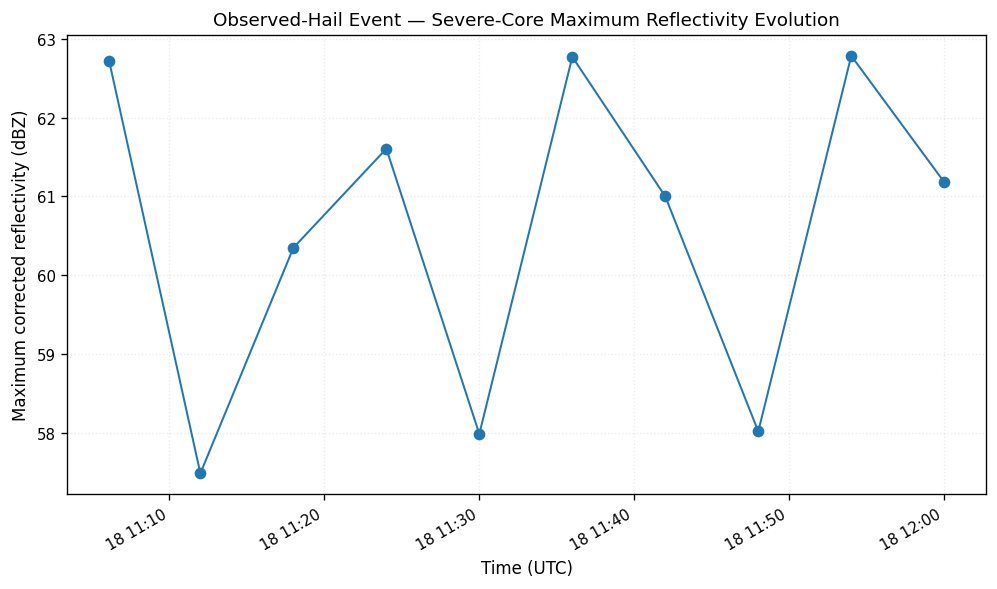

In [39]:
# CELL 39 — Maximum ZH lifecycle figure

fig = plt.figure(
    figsize=(
        8.2,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "maximum_ZH_dBZ"
    ],
    marker="o",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Maximum corrected reflectivity (dBZ)"
)

ax.set_title(
    "Observed-Hail Event — Severe-Core Maximum Reflectivity Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig11_lifecycle_maximum_ZH.png"
)

save_figure(
    fig,
    F,
    product="severe-core maximum reflectivity lifecycle",
    units="dBZ",
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig12_lifecycle_height_of_max_ZH.png


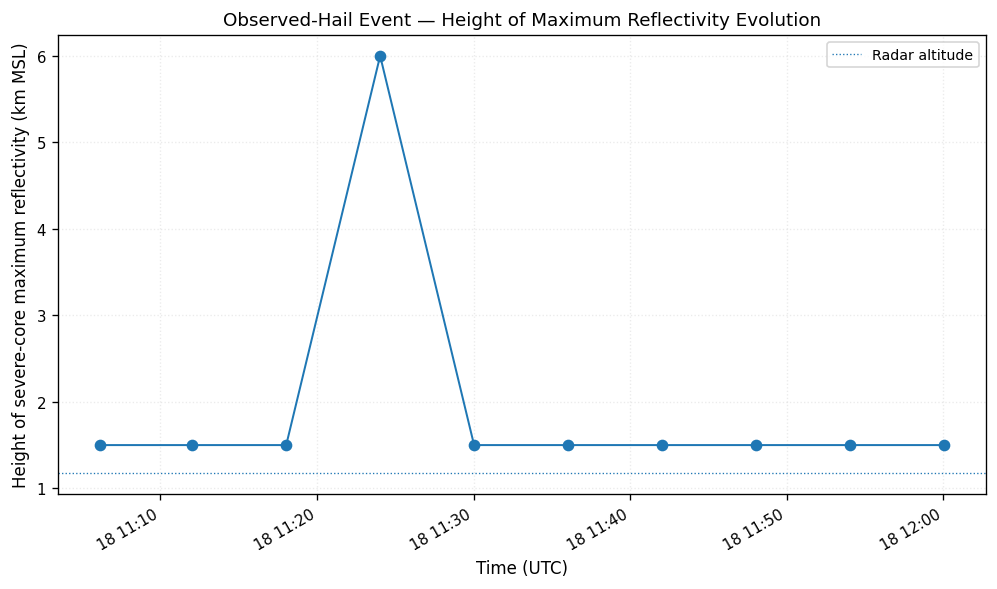

In [40]:
# CELL 40 — Height of maximum ZH lifecycle figure

fig = plt.figure(
    figsize=(
        8.2,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "height_of_core_maximum_ZH_km_MSL"
    ],
    marker="o",
)

ax.axhline(
    RADAR_ALTITUDE_KM_MSL,
    linestyle=":",
    linewidth=0.8,
    label="Radar altitude",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Height of severe-core maximum reflectivity (km MSL)"
)

ax.set_title(
    "Observed-Hail Event — Height of Maximum Reflectivity Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig12_lifecycle_height_of_max_ZH.png"
)

save_figure(
    fig,
    F,
    product="height of maximum reflectivity lifecycle",
    units="km MSL",
)

plt.show()

# 34. ET40 และ ET50 lifecycle

ET40 และ ET50 ช่วยดูว่า strong/intense core ขยายขึ้นหรือลดลงตามเวลา

การเพิ่มขึ้นของ ET50 อาจสะท้อน deepening ของ intense core

แต่ไม่ควรแปลโดยลำพังว่า:

```text
ET50 increase = hail growth at surface
```

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig13_lifecycle_ET40_ET50.png


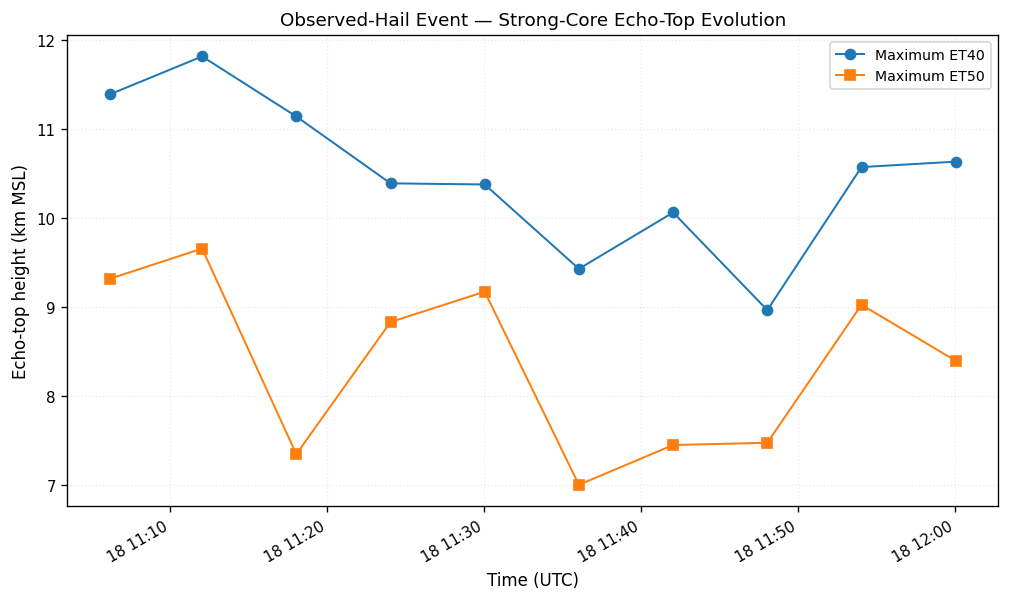

In [41]:
# CELL 41 — ET40 / ET50 lifecycle figure

fig = plt.figure(
    figsize=(
        8.3,
        4.9,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "maximum_ET40_km_MSL"
    ],
    marker="o",
    label="Maximum ET40",
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "maximum_ET50_km_MSL"
    ],
    marker="s",
    label="Maximum ET50",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Echo-top height (km MSL)"
)

ax.set_title(
    "Observed-Hail Event — Strong-Core Echo-Top Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig13_lifecycle_ET40_ET50.png"
)

save_figure(
    fig,
    F,
    product="ET40 and ET50 lifecycle",
    units="km MSL",
)

plt.show()

# 35. VIL56 lifecycle

VIL56 รวมข้อมูล reflectivity ในแนวดิ่ง

ดังนั้น VIL สามารถเพิ่มจาก:

- reflectivity สูงขึ้น
- strong echo layer ลึกขึ้น
- ทั้งสองอย่างพร้อมกัน

นี่คือเหตุผลที่ VIL ให้ข้อมูลต่างจาก maximum ZH

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig14_lifecycle_VIL56.png


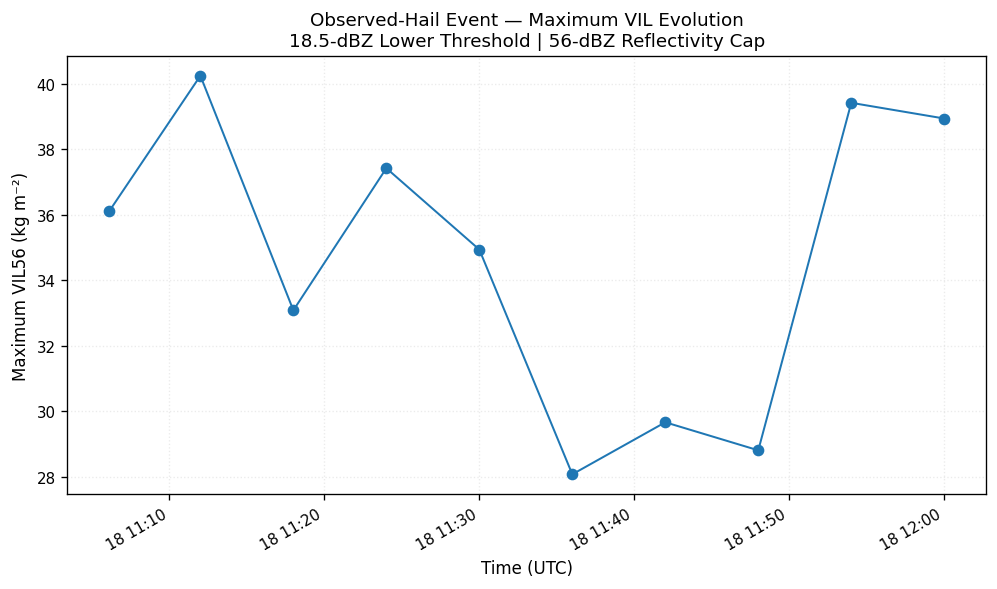

In [42]:
# CELL 42 — VIL56 lifecycle figure

fig = plt.figure(
    figsize=(
        8.2,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "maximum_VIL56_kg_m2"
    ],
    marker="o",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Maximum VIL56 (kg m⁻²)"
)

ax.set_title(
    (
        "Observed-Hail Event — Maximum VIL Evolution\n"
        "18.5-dBZ Lower Threshold | 56-dBZ Reflectivity Cap"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig14_lifecycle_VIL56.png"
)

save_figure(
    fig,
    F,
    product="maximum VIL56 lifecycle",
    units="kg m-2",
)

plt.show()

# 36. VIL density lifecycle

แสดงทั้ง:

```text
VILD18-ARL
VILD18-depth
```

เพื่อให้นิสิตเห็นว่าการเลือก denominator มีผลต่อ metric

ทั้งสองมีหน่วยเหมือนกัน แต่ความหมายเชิง sampling ต่างกัน

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig15_lifecycle_VILD.png


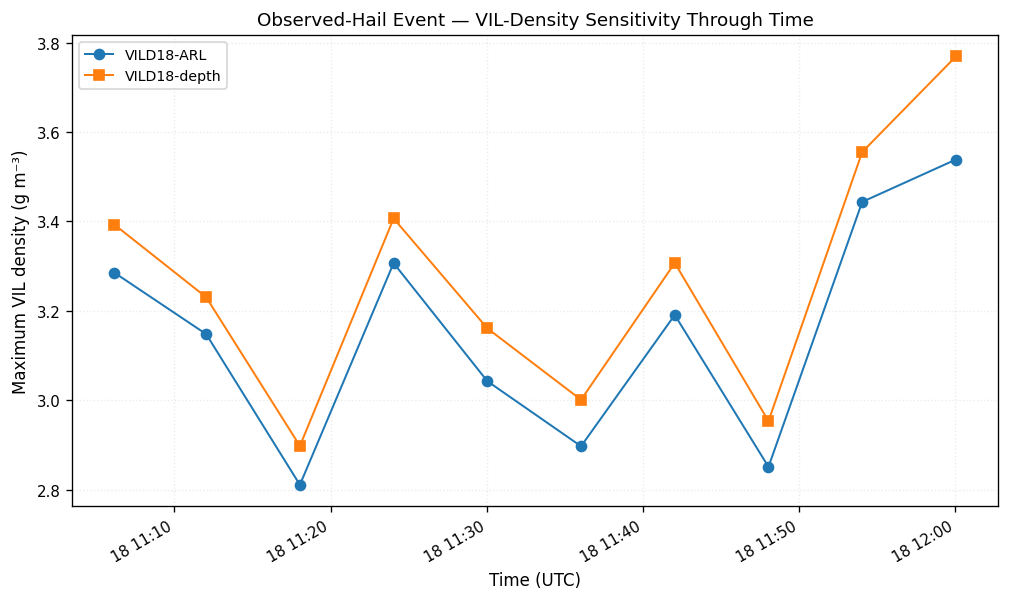

In [43]:
# CELL 43 — VILD lifecycle figure

fig = plt.figure(
    figsize=(
        8.3,
        4.9,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "maximum_VILD18_ARL_g_m3"
    ],
    marker="o",
    label="VILD18-ARL",
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "maximum_VILD18_depth_g_m3"
    ],
    marker="s",
    label="VILD18-depth",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Maximum VIL density (g m⁻³)"
)

ax.set_title(
    "Observed-Hail Event — VIL-Density Sensitivity Through Time"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig15_lifecycle_VILD.png"
)

save_figure(
    fig,
    F,
    product="VIL density lifecycle",
    interpretation=(
        "No external severe-hail threshold applied."
    ),
    units="g m-3",
)

plt.show()

# 37. Echo-volume lifecycle

40-dBZ และ 50-dBZ echo volume ช่วยดูว่า intense radar volume:

```text
grows
contracts
deepens
weakens
```

ไม่ใช่เพียงดูค่าจุดสูงสุดหนึ่ง pixel

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig16_lifecycle_echo_volume.png


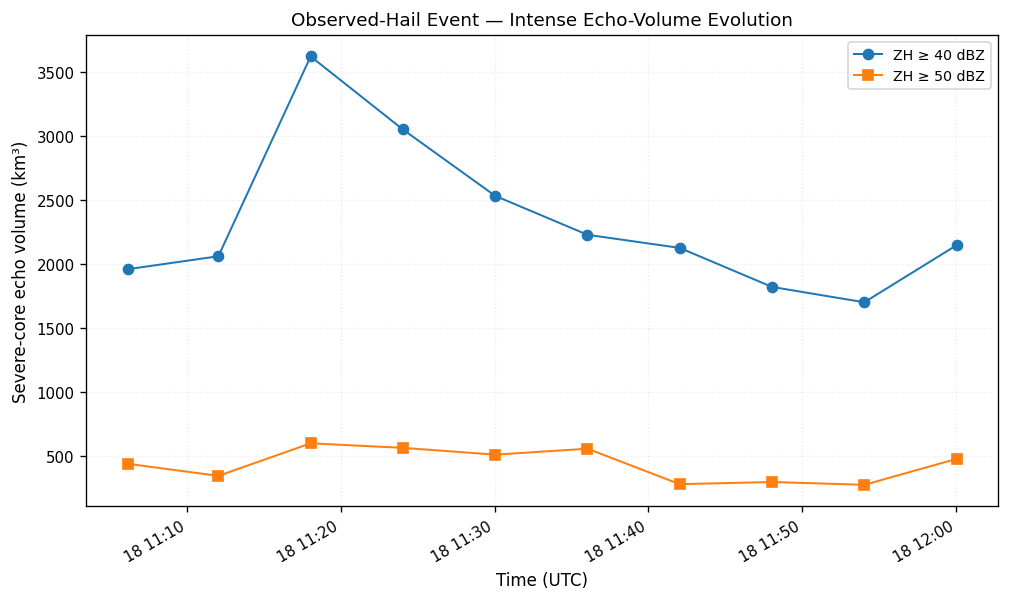

In [44]:
# CELL 44 — Echo-volume lifecycle figure

fig = plt.figure(
    figsize=(
        8.3,
        4.9,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "echo_volume_ge_40dBZ_km3"
    ],
    marker="o",
    label="ZH ≥ 40 dBZ",
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "echo_volume_ge_50dBZ_km3"
    ],
    marker="s",
    label="ZH ≥ 50 dBZ",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Severe-core echo volume (km³)"
)

ax.set_title(
    "Observed-Hail Event — Intense Echo-Volume Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig16_lifecycle_echo_volume.png"
)

save_figure(
    fig,
    F,
    product="40 and 50 dBZ echo-volume lifecycle",
    units="km3",
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/07/07_fig17_lifecycle_core_area.png


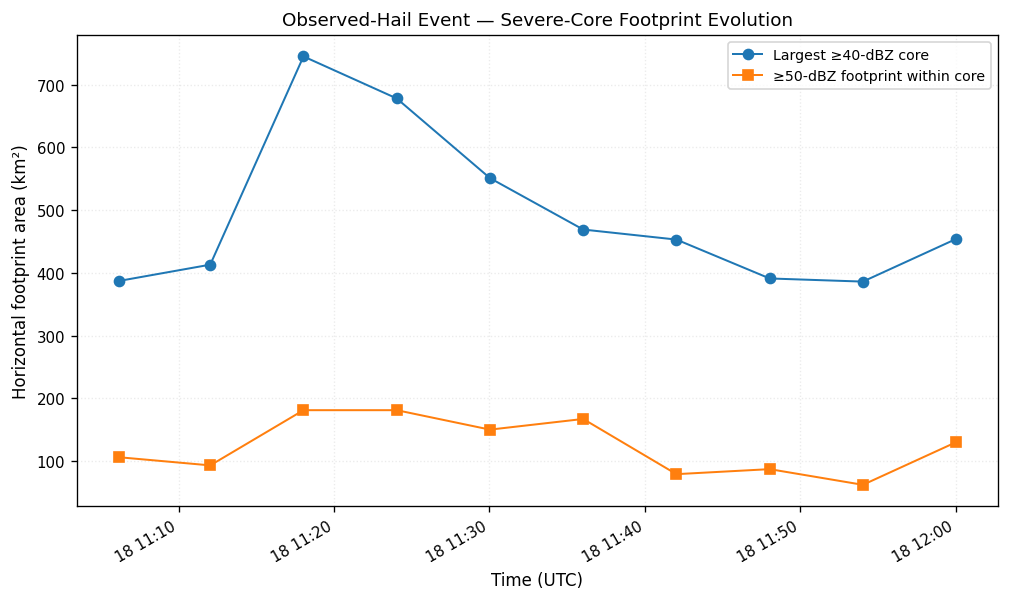

In [45]:
# CELL 45 — Core-footprint lifecycle figure

fig = plt.figure(
    figsize=(
        8.3,
        4.9,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "core_area_km2"
    ],
    marker="o",
    label="Largest ≥40-dBZ core",
)

ax.plot(
    LIFECYCLE_METRICS[
        "time_UTC"
    ],
    LIFECYCLE_METRICS[
        "intense_50dBZ_footprint_area_km2"
    ],
    marker="s",
    label="≥50-dBZ footprint within core",
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Horizontal footprint area (km²)"
)

ax.set_title(
    "Observed-Hail Event — Severe-Core Footprint Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "07_fig17_lifecycle_core_area.png"
)

save_figure(
    fig,
    F,
    product="severe-core footprint lifecycle",
    units="km2",
)

plt.show()

# 38. เวลา peak ของแต่ละ severe metric

Storm ไม่จำเป็นต้อง peak ทุก metric ในเวลาเดียวกัน

เช่น:

```text
maximum ZH peaks first
ET50 peaks later
VIL peaks later
echo volume peaks at another time
```

ความต่างของ timing สามารถให้ข้อมูลเกี่ยวกับ storm evolution

Notebook จึง export เวลาที่แต่ละ metric มีค่าสูงสุด

In [46]:
# CELL 46 — Peak timing table

PEAK_TIMING_VARIABLES = {
    "maximum_ZH_dBZ": "dBZ",
    "height_of_core_maximum_ZH_km_MSL": "km MSL",
    "maximum_ET40_km_MSL": "km MSL",
    "maximum_ET50_km_MSL": "km MSL",
    "maximum_VIL56_kg_m2": "kg m-2",
    "maximum_VILD18_ARL_g_m3": "g m-3",
    "maximum_VILD18_depth_g_m3": "g m-3",
    "core_area_km2": "km2",
    "intense_50dBZ_footprint_area_km2": "km2",
    "echo_volume_ge_40dBZ_km3": "km3",
    "echo_volume_ge_50dBZ_km3": "km3",
}

peak_timing_rows = []

for variable, units in (
    PEAK_TIMING_VARIABLES.items()
):
    series = (
        LIFECYCLE_METRICS[
            variable
        ]
    )

    valid = series.notna()

    if not valid.any():
        peak_timing_rows.append({
            "metric": (
                variable
            ),
            "peak_value": np.nan,
            "units": (
                units
            ),
            "peak_time_UTC": pd.NaT,
            "peak_time_ICT": pd.NaT,
            "filename": "",
        })

        continue

    index = series.idxmax()

    peak_timing_rows.append({
        "metric": (
            variable
        ),
        "peak_value": float(
            LIFECYCLE_METRICS.loc[
                index,
                variable
            ]
        ),
        "units": (
            units
        ),
        "peak_time_UTC": (
            LIFECYCLE_METRICS.loc[
                index,
                "time_UTC"
            ]
        ),
        "peak_time_ICT": (
            LIFECYCLE_METRICS.loc[
                index,
                "time_ICT"
            ]
        ),
        "filename": (
            LIFECYCLE_METRICS.loc[
                index,
                "filename"
            ]
        ),
    })


LIFECYCLE_PEAK_TIMING = pd.DataFrame(
    peak_timing_rows
)

display(
    LIFECYCLE_PEAK_TIMING
)

LIFECYCLE_PEAK_TIMING_CSV = (
    OUTPUT_CSV_DIR
    / "07_lifecycle_peak_timing.csv"
)

LIFECYCLE_PEAK_TIMING.to_csv(
    LIFECYCLE_PEAK_TIMING_CSV,
    index=False,
)

,metric,peak_value,units,peak_time_UTC,peak_time_ICT,filename
0,maximum_ZH_dBZ,62.783833,dBZ,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,20230318115402.uf.gz
1,height_of_core_maximum_ZH_km_MSL,6.000000,km MSL,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,20230318112402.uf.gz
2,maximum_ET40_km_MSL,11.815581,km MSL,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,20230318111202.uf.gz
3,maximum_ET50_km_MSL,9.659167,km MSL,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,20230318111202.uf.gz
4,maximum_VIL56_kg_m2,40.245372,kg m-2,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,20230318111202.uf.gz
5,maximum_VILD18_ARL_g_m3,3.538617,g m-3,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,20230318120002.uf.gz
6,maximum_VILD18_depth_g_m3,3.769429,g m-3,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,20230318120002.uf.gz
7,core_area_km2,745.000000,km2,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,20230318111802.uf.gz
8,intense_50dBZ_footprint_area_km2,181.000000,km2,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,20230318111802.uf.gz
9,echo_volume_ge_40dBZ_km3,3620.500000,km3,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,20230318111802.uf.gz


# 39. การตีความ severe-storm lifecycle อย่างมีเหตุผล

การดู time series หลาย metric พร้อมกันช่วยให้เข้าใจ storm evolution ดีกว่าดูตัวเดียว

ตัวอย่างแนวคิด:

```text
Max ZH increases
+
ET50 rises
+
VIL increases
+
50-dBZ echo volume expands
```

อาจสะท้อนการ deepening และ intensification ของ convective core

ในทางกลับกัน:

```text
Max ZH remains high
but
ET50 decreases
and
50-dBZ volume contracts
```

อาจสะท้อน core ที่ยัง intense เฉพาะบางส่วน แต่ vertical structure กำลังลดลง

> **สำคัญ**
>
> การกำหนด growth / mature / decay แบบ publication-grade ควรใช้เกณฑ์ที่ระบุชัด  
> Notebook นี้จึงไม่ assign phase labels อัตโนมัติจาก metric เดียว

# 40. VIL และ VILD ใน tropical hail research

VIL และ VILD เป็น diagnostic ที่มีประโยชน์ แต่มีข้อจำกัดหลายด้าน:

### Radar-related

- beam broadening
- incomplete low-level coverage
- interpolation
- calibration
- range dependence

### Microphysics-related

- hail contamination
- mixed-phase particles
- drop-size distribution
- wet hail / dry hail differences

### Environment-related

- tropical freezing level สูง
- warm-cloud depth
- storm depth
- thermodynamic profile

ดังนั้นในประเทศไทยควรใช้:

```text
VIL / VILD
as comparative physical diagnostics
```

ก่อนที่จะพัฒนาเป็น:

```text
validated hail thresholds
```

# 41. แนวทางเขียน Methods

Methods สำหรับ Notebook 07 ควรรายงานอย่างน้อย:

1. radar site และ band
2. source corrected-reflectivity field
3. Cartesian gridding method
4. horizontal / vertical resolution
5. ET thresholds
6. vertical interpolation method
7. grid-top censoring treatment
8. VIL formula
9. 18.5-dBZ lower threshold
10. 56-dBZ cap
11. VILD denominator definition
12. severe-core connected-component definition
13. 40-dBZ core threshold
14. dynamic-grid dimensions
15. core-localization search sector
16. lifecycle scan interval
17. edge-contact QC
18. statement that published foreign thresholds were not applied as deterministic hail criteria

ตัวอย่าง:

> Echo-top, VIL and severe-core diagnostics were derived from three-dimensional corrected-reflectivity grids. Threshold echo tops were calculated for 20, 30, 40 and 50 dBZ using linear interpolation between adjacent vertical grid levels where the reflectivity threshold was crossed; columns reaching the upper grid boundary were flagged as top censored. Vertically integrated liquid was calculated from linear reflectivity using the Greene–Clark formulation, retaining reflectivity ≥18.5 dBZ and truncating values above 56 dBZ for the primary VIL product. An uncapped VIL product was additionally calculated for sensitivity analysis. VIL density was evaluated using both the 18.5-dBZ echo-top height above radar level and the 18.5-dBZ echo depth. The largest connected composite-reflectivity footprint ≥40 dBZ was used as the severe-core object. Event evolution was evaluated for all ten radar volumes using a 1-km storm-following horizontal grid and the same vertical grid levels used for the peak-volume analysis.

ก่อนใช้ใน manuscript ให้ดึงค่าจริงจาก `07_processing_metadata.csv`

# 42. CORE — แบบฝึกหัดสำหรับปริญญาตรี

### แบบฝึกหัด 1 — Echo-top threshold

อธิบายว่าเหตุใด:

$$
ET_{20}
\ge
ET_{40}
\ge
ET_{50}
$$

โดยทั่วไป

### แบบฝึกหัด 2 — Composite ZH

อธิบายความต่างระหว่าง:

```text
Composite ZH
Height of maximum ZH
ET40
```

### แบบฝึกหัด 3 — VIL units

จาก:

$$
M\;[kg\,m^{-3}]
$$

และ:

$$
VIL
=
\int M\,dz
$$

แสดงว่า VIL มีหน่วย:

$$
kg\,m^{-2}
$$

### แบบฝึกหัด 4 — Footprint vs volume

อธิบายความต่างระหว่าง:

```text
40-dBZ footprint area [km²]
40-dBZ echo volume [km³]
```

# 43. ADVANCED / MSc — แบบฝึกหัด

### แบบฝึกหัด 5 — ET interpolation

สร้างตัวอย่าง:

```text
8.0 km = 45 dBZ
8.5 km = 35 dBZ
```

คำนวณ ET40 ด้วย linear interpolation

### แบบฝึกหัด 6 — VIL cap sensitivity

ใช้:

`07_peak_VIL_cap_sensitivity.csv`

ตอบ:

- maximum VIL56 เท่าใด?
- maximum uncapped VIL เท่าใด?
- cap มีผลมากที่สุดในบริเวณใด?

### แบบฝึกหัด 7 — VILD denominator

เปรียบเทียบ:

```text
VILD18-ARL
VILD18-depth
```

อธิบายว่าทำไมค่าทั้งสองต่างกันได้

### แบบฝึกหัด 8 — Lifecycle

ใช้:

`07_severe_storm_lifecycle_metrics.csv`

หาว่าเวลาใดมี:

- maximum ZH สูงสุด
- ET50 สูงสุด
- VIL56 สูงสุด
- 50-dBZ echo volume สูงสุด

peak times เหมือนกันหรือไม่?

# 44. RESEARCH — แบบฝึกหัดสำหรับต่อยอดตีพิมพ์

### แบบฝึกหัด 9 — VIL threshold sensitivity

ทดลอง:

```text
lower threshold = 15
18.5
20 dBZ
```

แล้วเปรียบเทียบ VIL

อภิปรายว่า low-reflectivity echo มีผลต่อ integrated quantity อย่างไร

### แบบฝึกหัด 10 — Reflectivity-cap sensitivity

ทดลอง:

```text
cap = 53
56
60 dBZ
no cap
```

เปรียบเทียบ peak VIL และ lifecycle ranking

### แบบฝึกหัด 11 — Vertical resolution

ถ้ามี grid:

```text
dz = 0.5 km
dz = 1.0 km
```

เปรียบเทียบ ET40 / ET50 หลัง interpolation

อภิปรายว่า interpolation ลด grid quantization ได้ แต่ไม่สร้าง observational resolution ใหม่

### แบบฝึกหัด 12 — Thailand-specific severe threshold

ออกแบบ validation study เพื่อประเมินว่า:

```text
ET50
VIL
VILD
50-dBZ echo volume
```

สามารถแยก:

```text
hail-producing
vs
non-hail severe convection
```

ในประเทศไทยได้หรือไม่

ควรมี:

- verified hail reports
- non-hail controls
- range stratification
- seasonal/environmental stratification
- ROC / POD / FAR / CSI
- uncertainty analysis

# 45. สิ่งที่ Notebook 07 ยังไม่ทำ

Notebook นี้ยังไม่ทำ:

- SHI
- MESH
- HSDA
- HDR
- HACC
- hydrometeor classification
- dual-pol hail size retrieval
- surface hail-size validation

เหตุผลคือ:

```text
Notebook 06
understand vertical structure

Notebook 07
derive severe-core metrics

Notebook 08
hail-specific retrieval
```

# 46. References ที่ใช้เป็นกรอบแนวคิด

### VIL

Greene, D. R., & Clark, R. A. (1972). Vertically integrated liquid water—A new analysis tool. *Monthly Weather Review, 100*(7), 548–552. https://doi.org/10.1175/1520-0493(1972)100<0548:VILWNA>2.3.CO;2

### VIL Density

Amburn, S. A., & Wolf, P. L. (1997). VIL density as a hail indicator. *Weather and Forecasting, 12*(3), 473–478. https://doi.org/10.1175/1520-0434(1997)012<0473:VDAAHI>2.0.CO;2

### Hail-oriented radar metrics and VIL-density considerations

Murillo, E. M., & Homeyer, C. R. (2019). Severe hail fall and hailstorm detection using remote sensing observations. *Journal of Applied Meteorology and Climatology, 58*(5), 947–970. https://doi.org/10.1175/JAMC-D-18-0247.1

> Published thresholds from these studies are background literature, not automatically calibrated thresholds for the Omkoi S-band radar or tropical Thailand.

# 47. Export processing metadata

In [47]:
# CELL 47 — Processing metadata

PROCESSING_METADATA = pd.DataFrame({
    "parameter": [
        "event_id",
        "event_type",
        "radar_site",
        "radar_band",
        "peak_source_file",
        "peak_source_grid",
        "reflectivity_field",
        "peak_grid_dx_km",
        "peak_grid_dy_km",
        "peak_grid_dz_km",
        "ET_thresholds_dBZ",
        "ET_vertical_interpolation",
        "ET_top_censoring",
        "VIL_lower_threshold_dBZ",
        "VIL_primary_cap_dBZ",
        "VIL_formula",
        "VILD_primary_definition",
        "VILD_secondary_definition",
        "published_VILD_hail_threshold_applied",
        "core_footprint_threshold_dBZ",
        "intense_core_threshold_dBZ",
        "connected_component_neighborhood",
        "lifecycle_volume_count",
        "lifecycle_grid_dx_km",
        "lifecycle_half_width_km",
        "lifecycle_vertical_levels_km_MSL",
        "core_search_half_angle_deg",
        "core_search_min_range_km",
        "core_search_max_range_km",
        "core_search_thresholds_dBZ",
        "dynamic_grid_edge_contact_count",
        "dynamic_core_search_fallback_count",
        "interpretation",
    ],
    "value": [
        ACTIVE_EVENT.get(
            "event_id"
        ),
        ACTIVE_EVENT.get(
            "event_type"
        ),
        "Omkoi",
        COURSE_CONFIG[
            "radar"
        ].get(
            "band"
        ),
        SELECTED_FILENAME,
        str(
            STORM_GRID_NETCDF
        ),
        FIELD_Z,
        STORM_DX_KM,
        STORM_DY_KM,
        STORM_DZ_KM,
        str(
            ET_THRESHOLDS_DBZ
        ),
        (
            "linear interpolation between the highest qualifying level "
            "and the next finite level"
        ),
        (
            "columns touching the upper grid level are flagged as censored"
        ),
        VIL_ECHO_THRESHOLD_DBZ,
        VIL_CAP_DBZ,
        (
            "VIL = 3.44e-6 integral(Z^(4/7) dz), "
            "Z in mm6 m-3 and dz in m"
        ),
        (
            "VIL56 divided by 18.5-dBZ echo-top height above radar level"
        ),
        (
            "VIL56 divided by 18.5-dBZ echo depth"
        ),
        False,
        CORE_FOOTPRINT_THRESHOLD_DBZ,
        INTENSE_CORE_THRESHOLD_DBZ,
        "8-neighbor 2-D connected component",
        len(
            LIFECYCLE_METRICS
        ),
        LIFECYCLE_GRID_DX_KM,
        LIFECYCLE_HALF_WIDTH_KM,
        str(
            STORM_Z_KM_MSL.tolist()
        ),
        CORE_SEARCH_HALF_ANGLE_DEG,
        CORE_SEARCH_MIN_RANGE_KM,
        CORE_SEARCH_MAX_RANGE_KM,
        str(
            CORE_SEARCH_THRESHOLDS_DBZ
        ),
        EDGE_CONTACT_COUNT,
        FALLBACK_CENTER_COUNT,
        (
            "Severe-storm radar diagnostics for an independently known "
            "observed-hail event. Metrics are not pixel-level hail truth "
            "and no foreign deterministic hail threshold is imposed."
        ),
    ],
})

display(
    PROCESSING_METADATA
)

PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "07_processing_metadata.csv"
)

PROCESSING_METADATA.to_csv(
    PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    PROCESSING_METADATA_CSV,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,radar_site,Omkoi
3,radar_band,S
4,peak_source_file,20230318111202.uf.gz
5,peak_source_grid,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
6,reflectivity_field,corrected_reflectivity
7,peak_grid_dx_km,0.5
8,peak_grid_dy_km,0.5
9,peak_grid_dz_km,0.5


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/07_processing_metadata.csv


# 48. Internal consistency checks

ก่อนสรุป severe-storm diagnostics จะตรวจ:

### Echo-top ordering

โดยทั่วไปควรได้:

$$
ET_{20}
\ge
ET_{30}
\ge
ET_{40}
\ge
ET_{50}
$$

ใน columns ที่ทุก threshold มีค่า

### Physical sign

```text
VIL ≥ 0
VILD ≥ 0
echo volume ≥ 0
core area ≥ 0
```

### Lifecycle completeness

```text
10 radar volumes
→ 10 lifecycle records
```

In [48]:
# CELL 48 — Echo-top hierarchy and physical-value checks

et20 = (
    PEAK_METRICS[
        "threshold_products"
    ][
        20.0
    ][
        "top_km_MSL"
    ]
)

et30 = (
    PEAK_METRICS[
        "threshold_products"
    ][
        30.0
    ][
        "top_km_MSL"
    ]
)

et40 = (
    PEAK_METRICS[
        "threshold_products"
    ][
        40.0
    ][
        "top_km_MSL"
    ]
)

et50 = (
    PEAK_METRICS[
        "threshold_products"
    ][
        50.0
    ][
        "top_km_MSL"
    ]
)

common_et = (
    np.isfinite(
        et20
    )
    & np.isfinite(
        et30
    )
    & np.isfinite(
        et40
    )
    & np.isfinite(
        et50
    )
)

ET_HIERARCHY_VIOLATIONS = int(
    (
        common_et
        & (
            (
                et20
                + 1e-6
                < et30
            )
            | (
                et30
                + 1e-6
                < et40
            )
            | (
                et40
                + 1e-6
                < et50
            )
        )
    ).sum()
)

PHYSICAL_CHECK_SUMMARY = pd.DataFrame({
    "metric": [
        "common_ET20_ET30_ET40_ET50_columns",
        "echo_top_hierarchy_violations",
        "negative_VIL56_pixels",
        "negative_VILD18_ARL_pixels",
        "negative_VILD18_depth_pixels",
        "negative_lifecycle_core_area_records",
        "negative_lifecycle_echo_volume_records",
    ],
    "value": [
        int(
            common_et.sum()
        ),
        ET_HIERARCHY_VIOLATIONS,
        int(
            (
                np.isfinite(
                    PEAK_VIL56
                )
                & (
                    PEAK_VIL56
                    < 0.0
                )
            ).sum()
        ),
        int(
            (
                np.isfinite(
                    PEAK_VILD_ARL
                )
                & (
                    PEAK_VILD_ARL
                    < 0.0
                )
            ).sum()
        ),
        int(
            (
                np.isfinite(
                    PEAK_METRICS[
                        "VILD18_depth_g_m3"
                    ]
                )
                & (
                    PEAK_METRICS[
                        "VILD18_depth_g_m3"
                    ]
                    < 0.0
                )
            ).sum()
        ),
        int(
            (
                LIFECYCLE_METRICS[
                    "core_area_km2"
                ]
                < 0.0
            ).sum()
        ),
        int(
            (
                (
                    LIFECYCLE_METRICS[
                        "echo_volume_ge_40dBZ_km3"
                    ]
                    < 0.0
                )
                | (
                    LIFECYCLE_METRICS[
                        "echo_volume_ge_50dBZ_km3"
                    ]
                    < 0.0
                )
            ).sum()
        ),
    ],
})

display(
    PHYSICAL_CHECK_SUMMARY
)

PHYSICAL_CHECK_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "07_physical_consistency_checks.csv"
)

PHYSICAL_CHECK_SUMMARY.to_csv(
    PHYSICAL_CHECK_SUMMARY_CSV,
    index=False,
)

,metric,value
0,common_ET20_ET30_ET40_ET50_columns,1256
1,echo_top_hierarchy_violations,0
2,negative_VIL56_pixels,0
3,negative_VILD18_ARL_pixels,0
4,negative_VILD18_depth_pixels,0
5,negative_lifecycle_core_area_records,0
6,negative_lifecycle_echo_volume_records,0


# 49. Export figure manifest

In [49]:
# CELL 49 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "07_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

print(
    "Saved:",
    FIGURE_MANIFEST_CSV,
)

,figure_name,figure_path,product,source_file,field,units,dpi,threshold_dbz,interpolation,lower_threshold_dbz,upper_cap_dbz,interpretation,core_threshold_dbz
0,07_fig01_peak_composite_reflectivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,peak composite reflectivity,20230318111202.uf.gz,corrected_reflectivity,dBZ,300,NaN,NaN,NaN,NaN,NaN,NaN
1,07_fig02_peak_height_of_max_reflectivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,height of maximum reflectivity,20230318111202.uf.gz,NaN,km MSL,300,NaN,NaN,NaN,NaN,NaN,NaN
2,07_peak_ET20.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,ET20,20230318111202.uf.gz,NaN,km MSL,300,20.0,linear vertical interpolation above highest qu...,NaN,NaN,NaN,NaN
3,07_peak_ET30.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,ET30,20230318111202.uf.gz,NaN,km MSL,300,30.0,linear vertical interpolation above highest qu...,NaN,NaN,NaN,NaN
4,07_peak_ET40.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,ET40,20230318111202.uf.gz,NaN,km MSL,300,40.0,linear vertical interpolation above highest qu...,NaN,NaN,NaN,NaN
5,07_peak_ET50.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,ET50,20230318111202.uf.gz,NaN,km MSL,300,50.0,linear vertical interpolation above highest qu...,NaN,NaN,NaN,NaN
6,07_fig07_peak_VIL56.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,VIL56,20230318111202.uf.gz,NaN,kg m-2,300,NaN,NaN,18.5,56.0,NaN,NaN
7,07_fig08_peak_VILD18_ARL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,VILD18 ARL,20230318111202.uf.gz,NaN,g m-3,300,NaN,NaN,NaN,NaN,Relative severe-core diagnostic; no imported h...,NaN
8,07_fig09_peak_VIL_cap_sensitivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,VIL cap sensitivity,20230318111202.uf.gz,NaN,kg m-2,300,NaN,NaN,NaN,NaN,NaN,NaN
9,07_fig10_peak_largest_40dBZ_core.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,largest 40-dBZ severe core,20230318111202.uf.gz,NaN,dBZ,300,NaN,NaN,NaN,NaN,NaN,40.0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/07_figure_manifest.csv


# 50. Output inventory

In [50]:
# CELL 50 — Output inventory

EXPECTED_OUTPUTS = [
    PEAK_METRIC_CSV,
    PEAK_ET_CENSORING_CSV,
    VIL_CAP_SENSITIVITY_CSV,
    PEAK_CORE_SUMMARY_CSV,
    PEAK_GEOTIFF_MANIFEST_CSV,
    PEAK_GEOTIFF_VALIDATION_CSV,
    LIFECYCLE_METRICS_CSV,
    LIFECYCLE_GRID_QC_CSV,
    LIFECYCLE_PEAK_TIMING_CSV,
    PROCESSING_METADATA_CSV,
    PHYSICAL_CHECK_SUMMARY_CSV,
    FIGURE_MANIFEST_CSV,
]

OUTPUT_INVENTORY = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
})

display(
    OUTPUT_INVENTORY
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 51. Final readiness check

In [51]:
# CELL 51 — Notebook 07 readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 03 readiness",
    bool(
        (
            readiness_03[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Notebook 06 readiness",
    bool(
        (
            readiness_06[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Active event is observed hail",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add_check(
    "Peak storm-focused 3-D grid readable",
    storm_grid is not None,
)

add_check(
    "Peak grid contains corrected reflectivity",
    FIELD_Z in storm_grid.fields,
)

add_check(
    "Four primary echo-top products calculated",
    all(
        threshold
        in PEAK_METRICS[
            "threshold_products"
        ]
        for threshold in (
            ET_THRESHOLDS_DBZ
        )
    ),
)

add_check(
    "Echo-top hierarchy internally consistent",
    ET_HIERARCHY_VIOLATIONS
    == 0,
    (
        f"violations = "
        f"{ET_HIERARCHY_VIOLATIONS}"
    ),
)

add_check(
    "VIL56 calculated",
    bool(
        np.isfinite(
            PEAK_VIL56
        ).any()
    ),
)

add_check(
    "Uncapped VIL sensitivity calculated",
    bool(
        np.isfinite(
            PEAK_VIL_UNCAPPED
        ).any()
    ),
)

add_check(
    "VILD18-ARL calculated",
    bool(
        np.isfinite(
            PEAK_VILD_ARL
        ).any()
    ),
)

add_check(
    "VILD18-depth calculated",
    bool(
        np.isfinite(
            PEAK_METRICS[
                "VILD18_depth_g_m3"
            ]
        ).any()
    ),
)

add_check(
    "Largest 40-dBZ severe core identified",
    bool(
        PEAK_SCALAR[
            "core_pixel_count"
        ]
        > 0
    ),
)

add_check(
    "Peak severe-core metrics exported",
    PEAK_CORE_SUMMARY_CSV.exists(),
)

add_check(
    "Peak severe-product GeoTIFFs exported",
    (
        len(
            PEAK_GEOTIFF_MANIFEST
        )
        == len(
            PEAK_GEOTIFF_PRODUCTS
        )
        and all(
            Path(
                path
            ).exists()
            for path in (
                PEAK_GEOTIFF_MANIFEST[
                    "path"
                ]
            )
        )
    ),
)

add_check(
    "Peak GeoTIFF validation exported",
    PEAK_GEOTIFF_VALIDATION_CSV.exists(),
)

add_check(
    "Ten radar volumes processed for lifecycle",
    len(
        LIFECYCLE_METRICS
    )
    == 10,
)

add_check(
    "All lifecycle records contain UTC time",
    bool(
        LIFECYCLE_METRICS[
            "time_UTC"
        ].notna().all()
    ),
)

add_check(
    "Lifecycle severe metrics exported",
    LIFECYCLE_METRICS_CSV.exists(),
)

add_check(
    "Lifecycle dynamic-grid QC exported",
    LIFECYCLE_GRID_QC_CSV.exists(),
    (
        f"edge-contact volumes = "
        f"{EDGE_CONTACT_COUNT}"
    ),
)

add_check(
    "Lifecycle peak timing exported",
    LIFECYCLE_PEAK_TIMING_CSV.exists(),
)

add_check(
    "No negative physical metrics detected",
    bool(
        (
            PHYSICAL_CHECK_SUMMARY.loc[
                PHYSICAL_CHECK_SUMMARY[
                    "metric"
                ].str.startswith(
                    "negative_"
                ),
                "value",
            ]
            == 0
        ).all()
    ),
)

add_check(
    "No deterministic foreign VILD hail threshold applied",
    True,
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)


READINESS_07 = pd.DataFrame(
    checks
)

display(
    READINESS_07
)

NOTEBOOK_07_READY = bool(
    (
        READINESS_07[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_07_CSV = (
    OUTPUT_CSV_DIR
    / "07_readiness_check.csv"
)

READINESS_07.to_csv(
    READINESS_07_CSV,
    index=False,
)

print()

print(
    (
        "NOTEBOOK 07 READY FOR "
        "HAIL-SPECIFIC RETRIEVAL AND MESH ANALYSIS"
    )
    if NOTEBOOK_07_READY
    else "NOTEBOOK 07 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 03 readiness,PASS,
1,Notebook 06 readiness,PASS,
2,Active event is observed hail,PASS,
3,Peak storm-focused 3-D grid readable,PASS,
4,Peak grid contains corrected reflectivity,PASS,
5,Four primary echo-top products calculated,PASS,
6,Echo-top hierarchy internally consistent,PASS,violations = 0
7,VIL56 calculated,PASS,
8,Uncapped VIL sensitivity calculated,PASS,
9,VILD18-ARL calculated,PASS,



NOTEBOOK 07 READY FOR HAIL-SPECIFIC RETRIEVAL AND MESH ANALYSIS


# ข้อความสำคัญที่ต้องจำ

1. **Echo top ขึ้นกับ reflectivity threshold**
2. ET20, ET30, ET40 และ ET50 ไม่ใช่ product เดียวกัน
3. Echo-top interpolation ลด vertical-grid quantization แต่ไม่สร้าง observational resolution ใหม่
4. Echo top แตะ grid ceiling ต้อง flag ว่า censored
5. Composite ZH บอก maximum intensity ใน column แต่ไม่บอกความสูงของ maximum
6. Height of maximum ZH ไม่ใช่ echo top
7. VIL เป็น reflectivity-derived equivalent-liquid proxy
8. VIL ไม่ใช่ measured storm liquid-water mass
9. VIL56 ใช้ 56-dBZ cap เพื่อลดอิทธิพลของ very high reflectivity/hail
10. Uncapped VIL ใช้เป็น sensitivity analysis
11. VILD ขึ้นกับ denominator definition
12. VILD18-ARL และ VILD18-depth ไม่จำเป็นต้องเท่ากัน
13. Threshold 3.5–4.0 g m⁻³ จากต่างประเทศไม่ใช่ deterministic Thailand threshold
14. 40-dBZ footprint area และ 40-dBZ echo volume เป็นคนละปริมาณ
15. Largest connected 40-dBZ core เป็น teaching storm-core object ไม่ใช่ formal tracking algorithm
16. Dynamic grid ช่วยตาม storm แต่ต้องตรวจ edge contact
17. Max ZH, ET50, VIL และ echo volume อาจ peak คนละเวลา
18. Storm lifecycle ควรใช้หลาย metrics ร่วมกัน
19. Observed hail ของกรณีศึกษานี้เป็น event-level independent information
20. Radar metrics ไม่ใช่ pixel-level surface hail truth
21. Notebook 08 จะเข้าสู่ hail-specific algorithms เช่น SHI / MESH / pyhail

# Expected outputs

```text
event-specific 03_output/csv/
├── 07_peak_severe_core_metrics.csv
├── 07_peak_echo_top_censoring.csv
├── 07_peak_VIL_cap_sensitivity.csv
├── 07_peak_core_object_summary.csv
├── 07_peak_GeoTIFF_manifest.csv
├── 07_peak_GeoTIFF_validation.csv
├── 07_severe_storm_lifecycle_metrics.csv
├── 07_lifecycle_dynamic_grid_QC.csv
├── 07_lifecycle_peak_timing.csv
├── 07_processing_metadata.csv
├── 07_physical_consistency_checks.csv
├── 07_figure_manifest.csv
└── 07_readiness_check.csv
```

```text
event-specific 03_output/geotiff/
├── 07_peak_composite_ZH_native_AEQD.tif
├── 07_peak_height_of_max_ZH_native_AEQD.tif
├── 07_peak_ET40_native_AEQD.tif
├── 07_peak_ET50_native_AEQD.tif
├── 07_peak_VIL56_native_AEQD.tif
└── 07_peak_VILD18_ARL_native_AEQD.tif
```

ตัวอย่าง figures:

```text
event-specific 04_figures/07/
├── peak composite reflectivity
├── height of maximum reflectivity
├── ET20
├── ET30
├── ET40
├── ET50
├── VIL56
├── VILD18-ARL
├── VIL-cap sensitivity
├── largest 40-dBZ severe core
├── maximum-ZH lifecycle
├── height-of-max-ZH lifecycle
├── ET40 / ET50 lifecycle
├── VIL lifecycle
├── VILD lifecycle
├── echo-volume lifecycle
└── core-area lifecycle
```

เมื่อ cell สุดท้ายแสดง:

```text
NOTEBOOK 07 READY FOR HAIL-SPECIFIC RETRIEVAL AND MESH ANALYSIS
```

จึงเข้าสู่:

**Notebook 08 — Hail Detection, SHI, MESH, HDR and pyhail**